In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
from torch.utils.data import random_split

class DINOTransform:
    def __init__(
        self,
        global_crop_size=64,
        local_crop_size=32,
        num_global_crops=2,
        num_local_crops=4,
        global_crop_scale=(0.5, 1.0),
        local_crop_scale=(0.2, 0.5),
    ):
        self.global_crop_size = global_crop_size
        self.local_crop_size = local_crop_size
        self.num_global_crops = num_global_crops
        self.num_local_crops = num_local_crops

        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(
                global_crop_size,
                scale=global_crop_scale,
                interpolation=transforms.InterpolationMode.BICUBIC,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.25,
                contrast=0.25,
                saturation=0.15,
                hue=0.05,
            ),
            transforms.RandomGrayscale(p=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
            ),
        ])

        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(
                local_crop_size,
                scale=local_crop_scale,
                interpolation=transforms.InterpolationMode.BICUBIC,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.25,
                contrast=0.25,
                saturation=0.15,
                hue=0.05,
            ),
            transforms.RandomGrayscale(p=0.1),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
            ),
        ])

    def __call__(self, image):
        crops = []

        for _ in range(self.num_global_crops):
            crops.append(self.global_transform(image))

        for _ in range(self.num_local_crops):
            crops.append(self.local_transform(image))

        return crops


def build_eval_transform(image_size=64):
    return transforms.Compose([
        transforms.Resize(
            (image_size, image_size),
            interpolation=transforms.InterpolationMode.BICUBIC,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),),])


class TinyImageNetDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, return_label=False):
        self.hf_dataset = hf_dataset
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]

        image = sample["image"].convert("RGB")
        label = sample["label"]

        if self.transform is not None:
            image = self.transform(image)

        if self.return_label:
            return image, label

        return image


def seed_worker(worker_id):
    worker_seed = DATA_CONFIG["seed"] + worker_id
    torch.manual_seed(worker_seed)


def build_tinyimagenet_dataloaders(config=DATA_CONFIG):
    """
    Construye datasets y dataloaders para Tiny ImageNet usando DINO multi-crop.

    El train_loader devuelve una lista de crops:
        crops = [
            global_crop_1,  # [B, 3, global_crop_size, global_crop_size]
            global_crop_2,  # [B, 3, global_crop_size, global_crop_size]
            local_crop_1,   # [B, 3, local_crop_size, local_crop_size]
            ...
        ]

    El val_loader devuelve:
        image, label

    porque validación se deja normal para inspección, kNN eval o linear probing.
    """

    torch.manual_seed(config["seed"])

    # --------------------------------------------------------
    # Cargar dataset desde Hugging Face
    # --------------------------------------------------------

    hf_dataset = load_dataset(config["dataset_name"])

    print("Available splits:", hf_dataset.keys())

    if "train" not in hf_dataset:
        raise ValueError(
            f"El dataset no tiene split 'train'. Splits disponibles: {list(hf_dataset.keys())}"
        )

    train_hf = hf_dataset["train"]

    # --------------------------------------------------------
    # Construir transforms
    # --------------------------------------------------------

    train_transform = DINOTransform(
        global_crop_size=config["global_crop_size"],
        local_crop_size=config["local_crop_size"],
        num_global_crops=config["num_global_crops"],
        num_local_crops=config["num_local_crops"],
        global_crop_scale=config["global_crop_scale"],
        local_crop_scale=config["local_crop_scale"],
    )

    val_transform = build_eval_transform(
        image_size=config["global_crop_size"]
    )

    # --------------------------------------------------------
    #  Detectar split de validación/test si existe
    # --------------------------------------------------------

    val_split_name = None

    for candidate in ["validation", "valid", "val", "test"]:
        if candidate in hf_dataset:
            val_split_name = candidate
            break

    # --------------------------------------------------------
    # Caso A: existe validation/valid/val/test
    # --------------------------------------------------------

    if val_split_name is not None:
        print(f"Using '{val_split_name}' as validation split.")

        val_hf = hf_dataset[val_split_name]

        train_dataset = TinyImageNetDataset(
            hf_dataset=train_hf,
            transform=train_transform,
            return_label=False,
        )

        val_dataset = TinyImageNetDataset(
            hf_dataset=val_hf,
            transform=val_transform,
            return_label=True,
        )

    # --------------------------------------------------------
    # Caso B: solo existe train, hacemos split manual
    # --------------------------------------------------------

    else:
        print("No validation/test split found. Creating manual train/val split.")

        full_train_dataset = TinyImageNetDataset(
            hf_dataset=train_hf,
            transform=train_transform,
            return_label=False,
        )

        full_val_dataset = TinyImageNetDataset(
            hf_dataset=train_hf,
            transform=val_transform,
            return_label=True,
        )

        val_ratio = config.get("val_ratio", 0.1)

        val_size = int(val_ratio * len(train_hf))
        train_size = len(train_hf) - val_size

        generator = torch.Generator().manual_seed(config["seed"])

        train_indices, val_indices = random_split(
            range(len(train_hf)),
            lengths=[train_size, val_size],
            generator=generator,
        )

        train_dataset = torch.utils.data.Subset(
            full_train_dataset,
            train_indices.indices,
        )

        val_dataset = torch.utils.data.Subset(
            full_val_dataset,
            val_indices.indices,
        )

    # --------------------------------------------------------
    # Crear DataLoaders
    # --------------------------------------------------------

    persistent_workers = (
        config["persistent_workers"]
        if config["num_workers"] > 0
        else False
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=config["shuffle_train"],
        num_workers=config["num_workers"],
        pin_memory=config["pin_memory"],
        persistent_workers=persistent_workers,
        drop_last=config["drop_last_train"],
        worker_init_fn=seed_worker,)

    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=config["pin_memory"],
        persistent_workers=persistent_workers,
        drop_last=config["drop_last_val"],
        worker_init_fn=seed_worker,)


    print("Train dataset size:", len(train_dataset))
    print("Val dataset size:", len(val_dataset))
    print("Number of global crops:", config["num_global_crops"])
    print("Number of local crops:", config["num_local_crops"])
    print("Global crop size:", config["global_crop_size"])
    print("Local crop size:", config["local_crop_size"])

    return train_dataset, val_dataset, train_loader, val_loader





In [ ]:
DATA_CONFIG = {
    "dataset_name": "mteb/tiny-imagenet",

    # Multi-crop DINO
    "global_crop_size": 64,
    "local_crop_size": 32,
    "num_global_crops": 2,
    "num_local_crops": 4,

    # Crop scales
    "global_crop_scale": (0.5, 1.0),
    "local_crop_scale": (0.2, 0.5),

    # DataLoader
    "batch_size": 32,
    "num_workers": 2,
    "pin_memory": True,
    "persistent_workers": True,
    "shuffle_train": True,
    "drop_last_train": True,
    "drop_last_val": False,

    # Manual split si el dataset solo tiene train
    "val_ratio": 0.1,

    # Reproducibilidad
    "seed": 42,
}

train_dataset, val_dataset, train_loader, val_loader = build_tinyimagenet_dataloaders(DATA_CONFIG)

batch = next(iter(train_loader))

print("Number of crops:", len(batch))

for i, crop in enumerate(batch):
    print(f"Crop {i} shape:", crop.shape)


Available splits: dict_keys(['train', 'valid'])
Using 'valid' as validation split.
Train dataset size: 100000
Val dataset size: 10000
Number of global crops: 2
Number of local crops: 4
Global crop size: 64
Local crop size: 32
Number of crops: 6
Crop 0 shape: torch.Size([32, 3, 64, 64])
Crop 1 shape: torch.Size([32, 3, 64, 64])
Crop 2 shape: torch.Size([32, 3, 32, 32])
Crop 3 shape: torch.Size([32, 3, 32, 32])
Crop 4 shape: torch.Size([32, 3, 32, 32])
Crop 5 shape: torch.Size([32, 3, 32, 32])


In [ ]:
import matplotlib.pyplot as plt

def unnormalize_imagenet(x):
    """
    x: Tensor [3, H, W] normalizado con mean/std de ImageNet.
    return: Tensor [3, H, W] en rango aproximado [0, 1].
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3, 1, 1)

    x = x * std + mean
    x = x.clamp(0, 1)

    return x

def show_dino_batch_pretty(
    train_loader,
    num_images=6,
    num_global_crops=2,
    figsize_per_image=2.4,
    title="DINO multi-crop batch",
):
    """
    Visualización limpia de un batch DINO multi-crop.

    Estructura esperada del batch:
        batch[0:num_global_crops] -> global crops
        batch[num_global_crops:]  -> local crops

    Cada columna corresponde a una imagen original.
    Cada fila corresponde a un crop distinto.
    """

    batch = next(iter(train_loader))

    num_crops = len(batch)
    num_local_crops = num_crops - num_global_crops
    num_images = min(num_images, batch[0].shape[0])

    row_names = []
    for i in range(num_global_crops):
        row_names.append(f"Global {i + 1}")
    for i in range(num_local_crops):
        row_names.append(f"Local {i + 1}")

    fig, axes = plt.subplots(
        nrows=num_crops,
        ncols=num_images,
        figsize=(figsize_per_image * num_images, figsize_per_image * num_crops),
        squeeze=False)

    fig.suptitle(title, fontsize=18, y=1.01)

    for crop_idx, crop_batch in enumerate(batch):
        for img_idx in range(num_images):
            img = (
                unnormalize_imagenet(crop_batch[img_idx])
                .cpu()
                .permute(1, 2, 0))

            ax = axes[crop_idx, img_idx]
            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])

            # Título de columnas solo arriba
            if crop_idx == 0:
                ax.set_title(
                    f"Image {img_idx}",
                    fontsize=12,
                    pad=8)

            if img_idx == 0:
                ax.set_ylabel(
                    row_names[crop_idx],
                    fontsize=12,
                    rotation=0,
                    labelpad=45,
                    va="center",)

            # Borde visual distinto para global/local
            for spine in ax.spines.values():
                spine.set_linewidth(1.2)

                if crop_idx < num_global_crops:
                    spine.set_alpha(0.9)
                else:
                    spine.set_alpha(0.35)

    plt.tight_layout()
    plt.show()

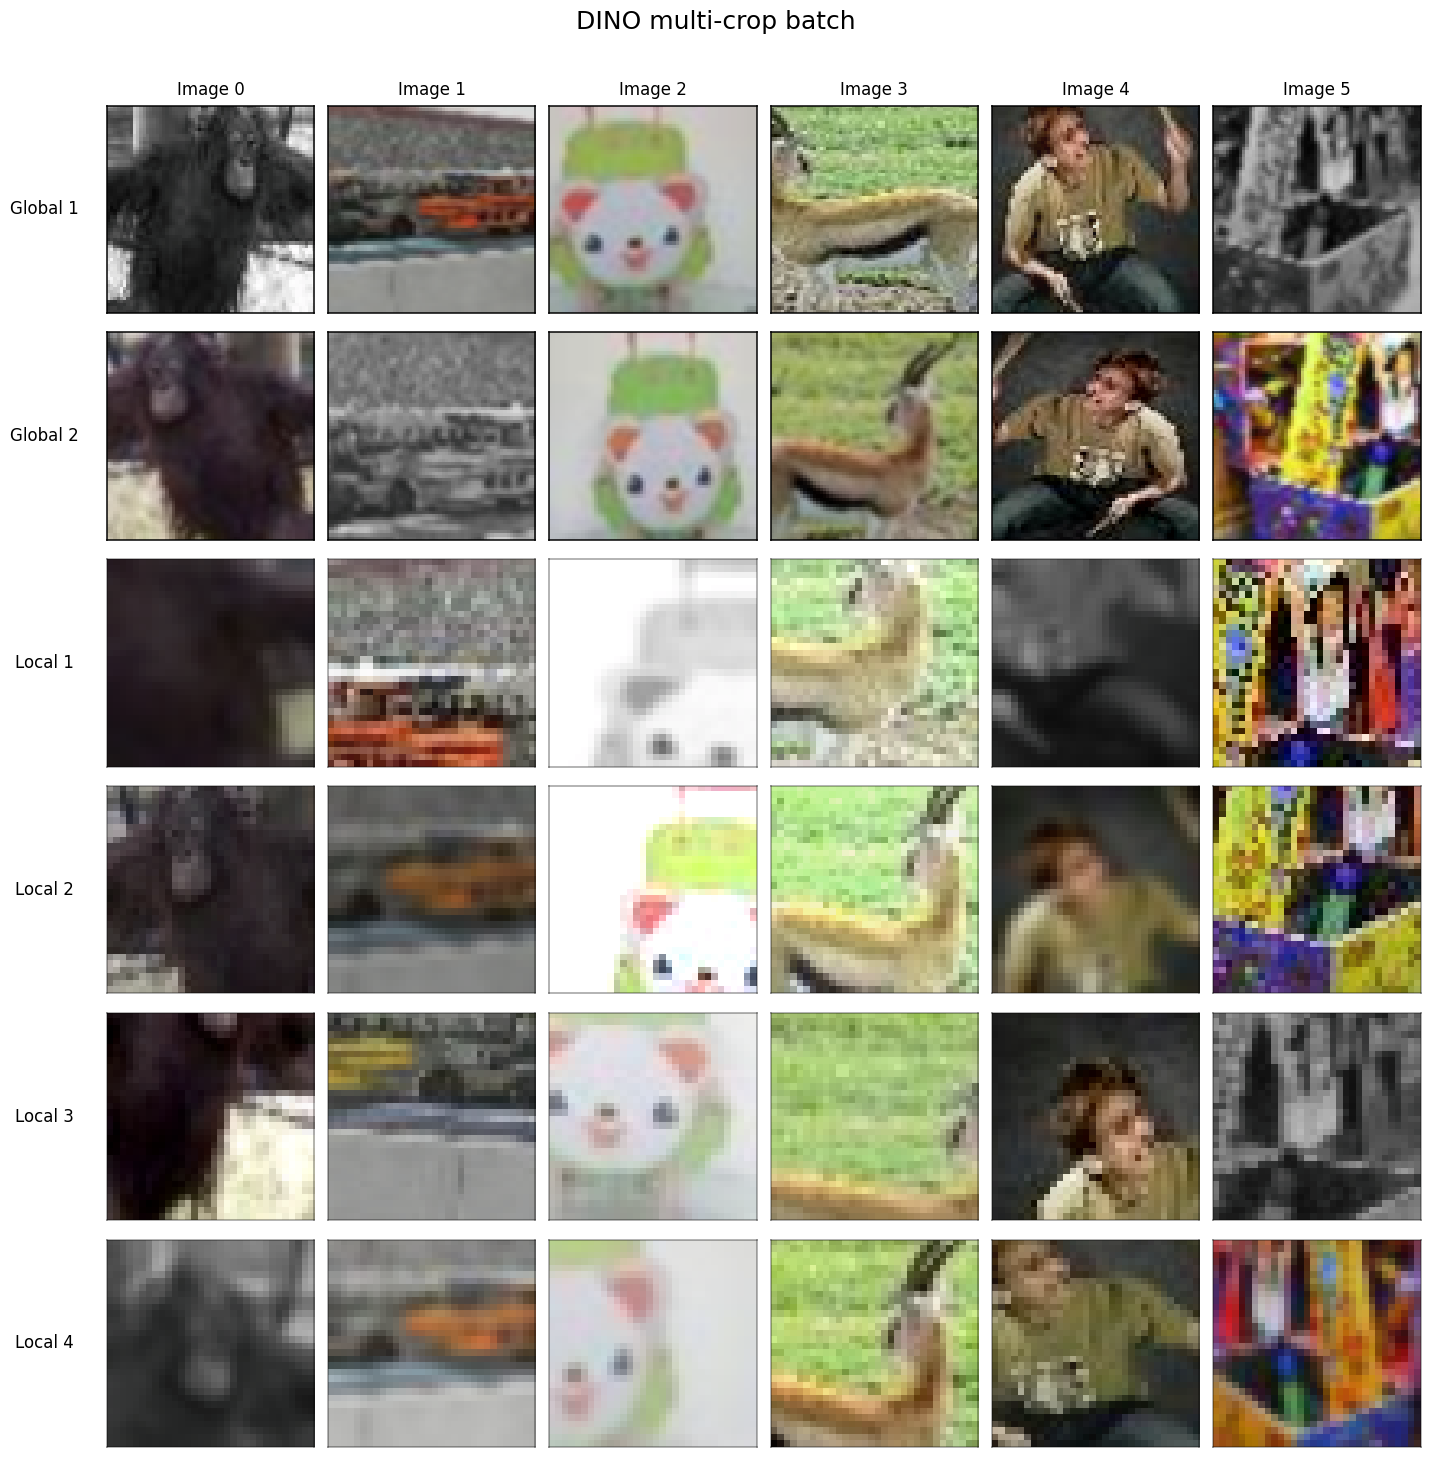

In [ ]:
show_dino_batch_pretty(
    train_loader,
    num_images=6,
    num_global_crops=DATA_CONFIG["num_global_crops"])

---

# Arquitecture

In [ ]:
from dataclasses import dataclass
from typing import Optional, Tuple, Union

import torch
import torch.nn as nn

Size2D = Union[int, Tuple[int, int]]


def to_2tuple(x: Size2D) -> Tuple[int, int]:
    if isinstance(x, int):
        return (x, x)
    if isinstance(x, tuple) and len(x) == 2:
        return x
    raise ValueError(f"Expected int or tuple[int, int], got {x}")

@dataclass
class PatchEmbeddingOutput:
    tokens: torch.Tensor              # [B, N, D]
    grid_size: Tuple[int, int]         # (Gh, Gw)
    num_patches: int                   # Gh * Gw
    patch_size: Tuple[int, int]        # (Ph, Pw)


class PatchEmbedding(nn.Module):
    """
    Image to patch-token embedding.

    This module only performs:
        image -> Conv2d patch projection -> flattened patch tokens

    It does NOT add:
        - CLS token
        - register tokens
        - learned positional embeddings
        - RoPE

    Reason:
        CLS/register/positional logic belongs to the ViT backbone, not to the
        patch embedding layer. For RoPE, we return grid_size so the attention
        module can construct/apply 2D rotary positions correctly.

    Parameters
    ----------
    img_size:
        Reference image size. Used only to compute the nominal grid_size and
        num_patches. Forward can still accept other divisible sizes if
        strict_img_size=False.

    patch_size:
        Patch size used by the Conv2d projection.

    in_chans:
        Number of image channels.

    embed_dim:
        Token embedding dimension.

    norm_layer:
        Optional normalization over patch tokens.

    flatten:
        If True, returns [B, N, D].
        If False, returns [B, D, Gh, Gw].

    strict_img_size:
        If True, forward requires input size == img_size.
        If False, any input divisible by patch_size is allowed.
        For DINO multi-crop, this should usually be False.
    """

    def __init__(
        self,
        img_size: Size2D = 64,
        patch_size: Size2D = 8,
        in_chans: int = 3,
        embed_dim: int = 192,
        norm_layer: Optional[type[nn.Module]] = None,
        flatten: bool = True,
        strict_img_size: bool = False,
        bias: bool = True,):

        super().__init__()

        self.img_size = to_2tuple(img_size)
        self.patch_size = to_2tuple(patch_size)
        self.flatten = flatten
        self.strict_img_size = strict_img_size
        self.embed_dim = embed_dim
        self.in_chans = in_chans

        img_h, img_w = self.img_size
        patch_h, patch_w = self.patch_size

        if img_h % patch_h != 0 or img_w % patch_w != 0:
            raise ValueError(
                f"img_size={self.img_size} must be divisible by "
                f"patch_size={self.patch_size}."
            )

        self.grid_size = (
            img_h // patch_h,
            img_w // patch_w,
        )
        self.num_patches = self.grid_size[0] * self.grid_size[1]

        self.proj = nn.Conv2d(
            in_channels=in_chans,
            out_channels=embed_dim,
            kernel_size=self.patch_size,
            stride=self.patch_size,
            bias=bias,
        )

        self.norm = norm_layer(embed_dim) if norm_layer is not None else nn.Identity()

    def forward(
        self,
        x: torch.Tensor,
        return_metadata: bool = True,
    ) -> PatchEmbeddingOutput | torch.Tensor:
        """
        Parameters
        ----------
        x:
            Image tensor of shape [B, C, H, W].

        return_metadata:
            If True, returns PatchEmbeddingOutput.
            If False, returns only patch tokens.

        Returns
        -------
        PatchEmbeddingOutput or Tensor
            tokens: [B, N, D] if flatten=True.
        """

        if x.ndim != 4:
            raise ValueError(
                f"Expected input of shape [B, C, H, W], got {tuple(x.shape)}."
            )

        batch_size, channels, height, width = x.shape

        if channels != self.in_chans:
            raise ValueError(
                f"Expected {self.in_chans} input channels, got {channels}."
            )

        if self.strict_img_size and (height, width) != self.img_size:
            raise ValueError(
                f"Input image size {(height, width)} does not match "
                f"configured img_size={self.img_size}. "
                f"Set strict_img_size=False to allow multi-crop inputs.")

        patch_h, patch_w = self.patch_size

        if height % patch_h != 0 or width % patch_w != 0:
            raise ValueError(
                f"Input image size {(height, width)} must be divisible by "
                f"patch_size={self.patch_size}.")

        x = self.proj(x)  # [B, D, Gh, Gw]

        grid_size = (x.shape[-2], x.shape[-1])
        num_patches = grid_size[0] * grid_size[1]

        if self.flatten:
            x = x.flatten(2).transpose(1, 2)  # [B, N, D]
            x = self.norm(x)

        if not return_metadata:
            return x

        return PatchEmbeddingOutput(
            tokens=x,
            grid_size=grid_size,
            num_patches=num_patches,
            patch_size=self.patch_size,
        )

In [ ]:
patch_embed = PatchEmbedding(
    img_size=64,
    patch_size=8,
    in_chans=3,
    embed_dim=192,
    norm_layer=None,
    flatten=True,
    strict_img_size=False,)

x_global = torch.randn(4, 3, 64, 64)
x_local = torch.randn(4, 3, 32, 32)

out_global = patch_embed(x_global)
out_local = patch_embed(x_local)

print(out_global.tokens.shape, out_global.grid_size)
print(out_local.tokens.shape, out_local.grid_size)

torch.Size([4, 64, 192]) (8, 8)
torch.Size([4, 16, 192]) (4, 4)


---

# Arquitecture helpers

In [ ]:
class DropPath(nn.Module):
    """
    Stochastic depth per sample.

    This is commonly used in ViT/DeiT/DINO-style models.
    """

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x

        keep_prob = 1.0 - self.drop_prob

        if keep_prob <= 0.0:
            return torch.zeros_like(x)

        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        random_tensor = random_tensor.div(keep_prob)

        return x * random_tensor


class FeedForward(nn.Module):
    """
    Standard ViT MLP block.

    Structure:
        Linear -> GELU -> Dropout -> Linear -> Dropout
    """

    def __init__(
        self,
        dim: int,
        hidden_dim: Optional[int] = None,
        mlp_ratio: float = 4.0,
        dropout: float = 0.0,
        act_layer: type[nn.Module] = nn.GELU,
        bias: bool = True,
    ):
        super().__init__()

        if hidden_dim is None:
            hidden_dim = int(dim * mlp_ratio)

        self.fc1 = nn.Linear(dim, hidden_dim, bias=bias)
        self.act = act_layer()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, dim, bias=bias)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)

        return x

---

# RoPe

In [ ]:
from typing import Optional, Callable, Tuple


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    """
    Rotates pairs of features:
        [x1, x2] -> [-x2, x1]
    """
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]

    x_rotated = torch.stack((-x_odd, x_even), dim=-1)
    x_rotated = x_rotated.flatten(-2)

    return x_rotated


class RotaryEmbedding2D(nn.Module):
    """
    2D axial RoPE for ViT patch tokens.

    This module builds rotary frequencies for a patch grid (Gh, Gw) and applies
    them to q and k patch tokens.

    Expected q/k shape:
        [B, num_heads, N_patch, head_dim]

    RoPE is applied only to patch tokens, not to CLS/register tokens.
    """

    def __init__(
        self,
        head_dim: int,
        base: float = 10000.0,
    ):
        super().__init__()

        if head_dim % 4 != 0:
            raise ValueError(
                f"For 2D RoPE, head_dim must be divisible by 4. Got head_dim={head_dim}."
            )

        self.head_dim = head_dim
        self.base = base

        # Half of head_dim goes to height, half to width.
        self.axis_dim = head_dim // 2

        inv_freq = 1.0 / (
            base ** (
                torch.arange(0, self.axis_dim, 2).float() / self.axis_dim
            )
        )

        self.register_buffer("inv_freq", inv_freq, persistent=False)

    def _build_2d_cos_sin(
        self,
        grid_size: Tuple[int, int],
        device: torch.device,
        dtype: torch.dtype,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        gh, gw = grid_size

        y = torch.arange(gh, device=device, dtype=self.inv_freq.dtype)
        x = torch.arange(gw, device=device, dtype=self.inv_freq.dtype)

        yy, xx = torch.meshgrid(y, x, indexing="ij")

        yy = yy.reshape(-1)  # [N]
        xx = xx.reshape(-1)  # [N]

        freqs_y = torch.einsum("n,d->nd", yy, self.inv_freq)  # [N, axis_dim/2]
        freqs_x = torch.einsum("n,d->nd", xx, self.inv_freq)  # [N, axis_dim/2]

        emb_y = torch.cat([freqs_y, freqs_y], dim=-1)  # [N, axis_dim]
        emb_x = torch.cat([freqs_x, freqs_x], dim=-1)  # [N, axis_dim]

        emb = torch.cat([emb_y, emb_x], dim=-1)  # [N, head_dim]

        cos = emb.cos().to(dtype=dtype)[None, None, :, :]  # [1, 1, N, head_dim]
        sin = emb.sin().to(dtype=dtype)[None, None, :, :]  # [1, 1, N, head_dim]

        return cos, sin

    def forward(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        grid_size: Tuple[int, int],
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        q, k:
            [B, num_heads, N_patch, head_dim]
        """

        expected_num_patches = grid_size[0] * grid_size[1]

        if q.shape[-2] != expected_num_patches:
            raise ValueError(
                f"q has {q.shape[-2]} patch tokens, but grid_size={grid_size} "
                f"implies {expected_num_patches} patches."
            )

        if k.shape[-2] != expected_num_patches:
            raise ValueError(
                f"k has {k.shape[-2]} patch tokens, but grid_size={grid_size} "
                f"implies {expected_num_patches} patches."
            )

        cos, sin = self._build_2d_cos_sin(
            grid_size=grid_size,
            device=q.device,
            dtype=q.dtype,
        )

        q = (q * cos) + (rotate_half(q) * sin)
        k = (k * cos) + (rotate_half(k) * sin)

        return q, k



---

# Attention

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention with optional 2D RoPE over patch tokens.

    Input:
        x: [B, T, D]

    If use_rope=True:
        - grid_size must be provided.
        - num_special_tokens tells how many leading tokens are not spatial:
            CLS + register tokens.
        - RoPE is applied only to patch tokens.
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        qkv_bias: bool = True,
        attn_dropout: float = 0.0,
        proj_dropout: float = 0.0,
        use_rope: bool = False,
        rope_base: float = 10000.0,
    ):
        super().__init__()

        if dim % num_heads != 0:
            raise ValueError(
                f"dim must be divisible by num_heads. Got dim={dim}, num_heads={num_heads}."
            )

        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.use_rope = use_rope

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)

        self.attn_drop = nn.Dropout(attn_dropout)

        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_dropout)

        if use_rope:
            self.rope = RotaryEmbedding2D(
                head_dim=self.head_dim,
                base=rope_base,
            )
        else:
            self.rope = None

    def forward(
        self,
        x: torch.Tensor,
        grid_size: Optional[Tuple[int, int]] = None,
        num_special_tokens: int = 1,
        return_attention: bool = False,
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        batch_size, num_tokens, dim = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(
            batch_size,
            num_tokens,
            3,
            self.num_heads,
            self.head_dim,
        )
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv.unbind(dim=0)
        # q, k, v: [B, H, T, head_dim]

        if self.use_rope:
            if grid_size is None:
                raise ValueError("grid_size must be provided when use_rope=True.")

            num_patch_tokens = grid_size[0] * grid_size[1]
            expected_tokens = num_special_tokens + num_patch_tokens

            if num_tokens != expected_tokens:
                raise ValueError(
                    f"Token mismatch: got num_tokens={num_tokens}, but "
                    f"num_special_tokens={num_special_tokens} and grid_size={grid_size} "
                    f"imply {expected_tokens} tokens."
                )

            q_special = q[:, :, :num_special_tokens, :]
            q_patch = q[:, :, num_special_tokens:, :]

            k_special = k[:, :, :num_special_tokens, :]
            k_patch = k[:, :, num_special_tokens:, :]

            q_patch, k_patch = self.rope(
                q=q_patch,
                k=k_patch,
                grid_size=grid_size,
            )

            q = torch.cat([q_special, q_patch], dim=2)
            k = torch.cat([k_special, k_patch], dim=2)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(batch_size, num_tokens, dim)

        out = self.proj(out)
        out = self.proj_drop(out)

        if return_attention:
            return out, attn

        return out

---

# Transformer Block

In [ ]:
class TransformerEncoderBlock(nn.Module):
    """
    PreNorm Transformer encoder block used in ViT.

    Supports optional RoPE through the attention module.
    """

    def __init__(
        self,
        dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        attn_dropout: float = 0.0,
        proj_dropout: float = 0.0,
        mlp_dropout: float = 0.0,
        drop_path: float = 0.0,
        use_rope: bool = False,
        rope_base: float = 10000.0,
        norm_layer: type[nn.Module] = nn.LayerNorm,
    ):
        super().__init__()

        self.norm1 = norm_layer(dim)

        self.attn = MultiHeadSelfAttention(
            dim=dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_dropout=attn_dropout,
            proj_dropout=proj_dropout,
            use_rope=use_rope,
            rope_base=rope_base,
        )

        self.drop_path1 = DropPath(drop_path)

        self.norm2 = norm_layer(dim)

        hidden_dim = int(dim * mlp_ratio)

        self.mlp = FeedForward(
            dim=dim,
            hidden_dim=hidden_dim,
            dropout=mlp_dropout,
        )

        self.drop_path2 = DropPath(drop_path)

    def forward(
        self,
        x: torch.Tensor,
        grid_size: Optional[Tuple[int, int]] = None,
        num_special_tokens: int = 1,
        return_attention: bool = False,
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        if return_attention:
            attn_out, attn = self.attn(
                self.norm1(x),
                grid_size=grid_size,
                num_special_tokens=num_special_tokens,
                return_attention=True,
            )

            x = x + self.drop_path1(attn_out)
            x = x + self.drop_path2(self.mlp(self.norm2(x)))

            return x, attn

        x = x + self.drop_path1(
            self.attn(
                self.norm1(x),
                grid_size=grid_size,
                num_special_tokens=num_special_tokens,
                return_attention=False,
            )
        )

        x = x + self.drop_path2(
            self.mlp(
                self.norm2(x)
            )
        )

        return x

In [ ]:
x = torch.randn(4, 65, 192)  # 1 CLS + 64 patches
grid_size = (8, 8)

block = TransformerEncoderBlock(
    dim=192,
    num_heads=3,
    mlp_ratio=4.0,
    use_rope=True,
)

y = block(
    x,
    grid_size=grid_size,
    num_special_tokens=1,
)

print(y.shape)

torch.Size([4, 65, 192])


In [ ]:
x_global = torch.randn(4, 65, 192)  # 1 CLS + 8x8 patches
x_local = torch.randn(4, 17, 192)   # 1 CLS + 4x4 patches

y_global = block(
    x_global,
    grid_size=(8, 8),
    num_special_tokens=1,
)

y_local = block(
    x_local,
    grid_size=(4, 4),
    num_special_tokens=1,
)

print(y_global.shape)
print(y_local.shape)

torch.Size([4, 65, 192])
torch.Size([4, 17, 192])


---

# Dino Arquitecture


In [ ]:
from typing import Optional, Tuple, Literal, Dict, Any

import torch
import torch.nn as nn
import torch.nn.functional as F

class VisionTransformer(nn.Module):
    """
    Plain Vision Transformer backbone adapted for DINO-style self-supervised learning.

    Supports:
        - learned absolute positional embeddings
        - 2D RoPE inside attention blocks
        - CLS token
        - optional register tokens
        - variable input crop sizes, e.g. 64x64 global crops and 32x32 local crops
        - returning CLS and patch tokens separately for DINO loss and Gram loss

    Expected dependencies:
        - PatchEmbedding
        - TransformerEncoderBlock

    The TransformerEncoderBlock should support:
        block(
            x,
            grid_size=grid_size,
            num_special_tokens=num_special_tokens,
            return_attention=False,
        )
    if using RoPE. If your block ignores these arguments, learned pos embeddings will still work.
    """

    def __init__(
        self,
        img_size: int | tuple[int, int] = 64,
        patch_size: int | tuple[int, int] = 8,
        in_chans: int = 3,
        num_classes: int = 0,
        embed_dim: int = 192,
        depth: int = 6,
        num_heads: int = 3,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        patch_norm: bool = False,
        drop_rate: float = 0.0,
        attn_dropout: float = 0.0,
        proj_dropout: float = 0.0,
        mlp_dropout: float = 0.0,
        drop_path_rate: float = 0.1,
        pos_embed_type: Literal["learned", "rope", "none"] = "learned",
        use_cls_token: bool = True,
        num_register_tokens: int = 0,
        rope_base: float = 10000.0,
        norm_layer: type[nn.Module] = nn.LayerNorm,
        strict_img_size: bool = False,
    ):
        super().__init__()

        if pos_embed_type not in {"learned", "rope", "none"}:
            raise ValueError(
                f"pos_embed_type must be one of 'learned', 'rope', or 'none'. "
                f"Got {pos_embed_type}."
            )

        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.num_classes = num_classes
        self.embed_dim = embed_dim
        self.num_features = embed_dim
        self.depth = depth
        self.num_heads = num_heads
        self.pos_embed_type = pos_embed_type
        self.use_cls_token = use_cls_token
        self.num_register_tokens = num_register_tokens

        self.num_special_tokens = int(use_cls_token) + num_register_tokens

        patch_norm_layer = norm_layer if patch_norm else None

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=patch_norm_layer,
            strict_img_size=strict_img_size,
        )

        self.num_patches = self.patch_embed.num_patches
        self.base_grid_size = self.patch_embed.grid_size

        # ----------------------------------------------------
        # Special tokens: CLS + registers
        # ----------------------------------------------------

        if use_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        else:
            self.cls_token = None

        if num_register_tokens > 0:
            self.register_tokens = nn.Parameter(
                torch.zeros(1, num_register_tokens, embed_dim)
            )
        else:
            self.register_tokens = None

        # ----------------------------------------------------
        # Positional embeddings
        # ----------------------------------------------------
        # Learned absolute embeddings are added only when pos_embed_type="learned".
        # RoPE is applied inside attention, so no absolute pos_embed is added here.

        if pos_embed_type == "learned":
            self.pos_embed = nn.Parameter(
                torch.zeros(
                    1,
                    self.num_special_tokens + self.num_patches,
                    embed_dim,))

        else:
            self.pos_embed = None

        self.pos_drop = nn.Dropout(drop_rate)

        # ----------------------------------------------------
        # Transformer blocks
        # ----------------------------------------------------

        drop_path_values = (
            torch.linspace(0, drop_path_rate, depth).tolist()
            if depth > 0
            else [])

        use_rope = pos_embed_type == "rope"

        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    dim=embed_dim,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    qkv_bias=qkv_bias,
                    attn_dropout=attn_dropout,
                    proj_dropout=proj_dropout,
                    mlp_dropout=mlp_dropout,
                    drop_path=drop_path_values[idx],
                    use_rope=use_rope,
                    rope_base=rope_base,
                    norm_layer=norm_layer,
                )
                for idx in range(depth)])

        self.norm = norm_layer(embed_dim)

        # Optional classification head. For DINO pretraining, usually num_classes=0.
        if num_classes > 0:
            self.head = nn.Linear(embed_dim, num_classes)
        else:
            self.head = nn.Identity()

        self._init_weights()

    # ========================================================
    # Initialization
    # ========================================================

    def _init_weights(self):
        if self.cls_token is not None:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        if self.register_tokens is not None:
            nn.init.trunc_normal_(self.register_tokens, std=0.02)

        if self.pos_embed is not None:
            nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)

            elif isinstance(module, nn.LayerNorm):
                nn.init.constant_(module.bias, 0.0)
                nn.init.constant_(module.weight, 1.0)

            elif isinstance(module, nn.Conv2d):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)

        if isinstance(self.head, nn.Linear):
            nn.init.trunc_normal_(self.head.weight, std=0.02)
            if self.head.bias is not None:
                nn.init.constant_(self.head.bias, 0.0)

    # ========================================================
    # Positional embedding interpolation
    # ========================================================

    def _interpolate_pos_encoding(
        self,
        grid_size: Tuple[int, int],
        dtype: torch.dtype,
        device: torch.device,) -> torch.Tensor:
        """
        Interpolates learned absolute positional embeddings to a target patch grid.

        This is needed because DINO uses multi-crop:
            global crop: 64x64 -> 8x8 patches
            local crop: 32x32  -> 4x4 patches

        Special tokens are not interpolated.
        Patch tokens are reshaped as a 2D grid and bicubically interpolated.
        """

        if self.pos_embed is None:
            raise RuntimeError(
                "_interpolate_pos_encoding was called but self.pos_embed is None.")

        target_h, target_w = grid_size
        base_h, base_w = self.base_grid_size

        num_target_patches = target_h * target_w

        special_pos = self.pos_embed[:, : self.num_special_tokens]
        patch_pos = self.pos_embed[:, self.num_special_tokens :]

        if (target_h, target_w) == (base_h, base_w):
            return self.pos_embed.to(device=device, dtype=dtype)

        patch_pos = patch_pos.reshape(
            1,
            base_h,
            base_w,
            self.embed_dim).permute(0, 3, 1, 2)


        patch_pos = F.interpolate(
            patch_pos,
            size=(target_h, target_w),
            mode="bicubic",
            align_corners=False)

        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(
            1,
            num_target_patches,
            self.embed_dim)

        pos_embed = torch.cat([special_pos, patch_pos], dim=1)

        return pos_embed.to(device=device, dtype=dtype)

    # ========================================================
    # Token preparation
    # ========================================================

    def _prepare_tokens(
        self,
        x: torch.Tensor) -> tuple[torch.Tensor, Tuple[int, int]]:
        """
        Converts image tensor into full ViT token sequence:

            image -> patch tokens
            prepend CLS token if enabled
            prepend register tokens if enabled
            add learned positional embeddings if enabled

        Token order:
            [CLS] [REG_1] ... [REG_R] [PATCH_1] ... [PATCH_N]

        This order is important because RoPE is applied only to patch tokens.
        """

        patch_out = self.patch_embed(x)

        # Compatible with either:
        #   old PatchEmbedding returning (tokens, grid_size)
        #   new PatchEmbedding returning PatchEmbeddingOutput
        if isinstance(patch_out, tuple):
            patch_tokens, grid_size = patch_out
        else:
            patch_tokens = patch_out.tokens
            grid_size = patch_out.grid_size

        batch_size = patch_tokens.shape[0]

        tokens = []

        if self.cls_token is not None:
            cls = self.cls_token.expand(batch_size, -1, -1)
            tokens.append(cls)

        if self.register_tokens is not None:
            registers = self.register_tokens.expand(batch_size, -1, -1)
            tokens.append(registers)

        tokens.append(patch_tokens)

        x = torch.cat(tokens, dim=1)

        if self.pos_embed_type == "learned":
            pos_embed = self._interpolate_pos_encoding(
                grid_size=grid_size,
                dtype=x.dtype,
                device=x.device)

            x = x + pos_embed

        x = self.pos_drop(x)

        return x, grid_size

    # ========================================================
    # Forward features
    # ========================================================

    def forward_features(
        self,
        x: torch.Tensor,
        return_all_tokens: bool = True,
        return_attention: bool = False) -> Dict[str, Any]:
        """
        Returns a dictionary useful for DINO:

            {
                "x_norm": full normalized sequence,
                "cls": CLS token or pooled token,
                "registers": register tokens or None,
                "patches": patch tokens,
                "grid_size": patch grid,
                "attentions": optional list of attention maps
            }
        """

        x, grid_size = self._prepare_tokens(x)

        attentions = [] if return_attention else None

        for block in self.blocks:
            if return_attention:
                x, attn = block(
                    x,
                    grid_size=grid_size,
                    num_special_tokens=self.num_special_tokens,
                    return_attention=True)

                attentions.append(attn)
            else:
                x = block(
                    x,
                    grid_size=grid_size,
                    num_special_tokens=self.num_special_tokens,
                    return_attention=False)

        x = self.norm(x)

        idx = 0

        if self.use_cls_token:
            cls = x[:, idx]
            idx += 1
        else:
            # If no CLS token exists, use mean pooling over patch tokens.
            cls = x[:, self.num_special_tokens :].mean(dim=1)

        if self.num_register_tokens > 0:
            registers = x[:, idx : idx + self.num_register_tokens]
            idx += self.num_register_tokens
        else:
            registers = None

        patch_tokens = x[:, idx:]

        out = {
            "cls": cls,                        # [B, D]
            "registers": registers,            # [B, R, D] or None
            "patches": patch_tokens,           # [B, N, D]
            "grid_size": grid_size,             # (Gh, Gw)
        }

        if return_all_tokens:
            out["x_norm"] = x                  # [B, T, D]

        if return_attention:
            out["attentions"] = attentions

        return out

    # ========================================================
    # Standard forward
    # ========================================================

    def forward(
        self,
        x: torch.Tensor,
        return_features: bool = False,
        return_all_tokens: bool = True,
        return_attention: bool = False):

        features = self.forward_features(
            x,
            return_all_tokens=return_all_tokens,
            return_attention=return_attention)

        if return_features:
            return features

        logits = self.head(features["cls"])

        return logits

In [ ]:
class DINOHead(nn.Module):
    """
    Projection head used for DINO-style self-distillation.

    Input:
        x: [B, in_dim]

    Output:
        logits: [B, out_dim]

    Canonical structure:
        MLP -> bottleneck -> L2 normalize -> weight-normalized linear layer
    """

    def __init__(
        self,
        in_dim: int,
        out_dim: int = 8192,
        hidden_dim: int = 2048,
        bottleneck_dim: int = 256,
        num_layers: int = 3,
        use_bn: bool = False,
        norm_last_layer: bool = True,
        bias: bool = True,
    ):
        super().__init__()

        if num_layers < 1:
            raise ValueError(f"num_layers must be >= 1, got {num_layers}")

        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.hidden_dim = int(hidden_dim)
        self.bottleneck_dim = int(bottleneck_dim)
        self.num_layers = int(num_layers)
        self.use_bn = bool(use_bn)
        self.norm_last_layer = bool(norm_last_layer)

        if num_layers == 1:
            self.mlp = nn.Linear(in_dim, bottleneck_dim, bias=bias)

        else:
            layers = []

            layers.append(nn.Linear(in_dim, hidden_dim, bias=bias))

            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_dim))

            layers.append(nn.GELU())

            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_dim, hidden_dim, bias=bias))

                if use_bn:
                    layers.append(nn.BatchNorm1d(hidden_dim))

                layers.append(nn.GELU())

            layers.append(nn.Linear(hidden_dim, bottleneck_dim, bias=bias))

            self.mlp = nn.Sequential(*layers)

        self.last_layer = nn.utils.weight_norm(
            nn.Linear(bottleneck_dim, out_dim, bias=False)
        )

        self.last_layer.weight_g.data.fill_(1.0)

        if norm_last_layer:
            self.last_layer.weight_g.requires_grad = False

        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)

            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)

        elif isinstance(module, nn.BatchNorm1d):
            nn.init.constant_(module.weight, 1.0)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        x = self.last_layer(x)

        return x

In [ ]:
class DINOModel(nn.Module):
    """
    Full DINO model:

        image
        -> VisionTransformer backbone
        -> CLS token
        -> DINOHead
        -> logits

    Also returns patch tokens for Gram loss.

    Expected backbone output when return_features=True:
        {
            "cls": Tensor[B, D],
            "patches": Tensor[B, N, D],
            "registers": Optional[Tensor[B, R, D]],
            "grid_size": tuple[int, int],
            ...
        }
    """

    def __init__(
        self,
        backbone: nn.Module,
        head: nn.Module,
        cls_key: str = "cls",
    ):
        super().__init__()

        self.backbone = backbone
        self.head = head
        self.cls_key = cls_key

    def forward(
        self,
        x: torch.Tensor,
        return_features: bool = True,
        return_all_tokens: bool = True,
        return_attention: bool = False,
    ) -> Dict[str, Any] | torch.Tensor:
        features = self.backbone(
            x,
            return_features=True,
            return_all_tokens=return_all_tokens,
            return_attention=return_attention,
        )

        if not isinstance(features, dict):
            raise TypeError(
                f"Backbone must return a dict when return_features=True. Got {type(features)}."
            )

        if self.cls_key not in features:
            raise KeyError(
                f"Backbone output does not contain cls_key='{self.cls_key}'. "
                f"Available keys: {list(features.keys())}"
            )

        cls = features[self.cls_key]
        logits = self.head(cls)

        features["logits"] = logits

        if return_features:
            return features

        return logits

---

# Wrapper DiNo

In [ ]:
import copy
import torch
import torch.nn as nn


def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    """
    Cuenta parámetros del modelo.
    """
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def freeze_model(model: nn.Module) -> nn.Module:
    """
    Congela todos los parámetros de un modelo.
    """
    for param in model.parameters():
        param.requires_grad = False
    return model


def build_dino_bundle(CFG: dict) -> dict:
    """
    Build a complete DINO bundle.

    Returns
    -------
    bundle_dino:
        {
            "student": DINOModel,
            "teacher": DINOModel,
            "config": CFG,
            "model_info": metadata,
            "device": device,
        }

    Notes
    -----
    - student contains backbone + DINOHead.
    - teacher is initialized as a deepcopy of student.
    - teacher is frozen.
    - teacher is updated with EMA during training.
    """

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = CFG.get(
        "device",
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    device = torch.device(device)

    # --------------------------------------------------------
    # Configs
    # --------------------------------------------------------

    model_cfg = CFG["model"]
    head_cfg = CFG.get("dino_head", {})

    embed_dim = int(model_cfg.get("embed_dim", 192))

    # --------------------------------------------------------
    # Student backbone
    # --------------------------------------------------------

    student_backbone = VisionTransformer(
        img_size=model_cfg.get("img_size", 64),
        patch_size=model_cfg.get("patch_size", 8),
        in_chans=model_cfg.get("in_chans", 3),

        # For DINO pretraining, classification head is not used.
        num_classes=0,

        embed_dim=embed_dim,
        depth=model_cfg.get("depth", 6),
        num_heads=model_cfg.get("num_heads", 3),
        mlp_ratio=model_cfg.get("mlp_ratio", 4.0),
        qkv_bias=model_cfg.get("qkv_bias", True),
        patch_norm=model_cfg.get("patch_norm", False),
        drop_rate=model_cfg.get("drop_rate", 0.0),
        attn_dropout=model_cfg.get("attn_dropout", 0.0),
        proj_dropout=model_cfg.get("proj_dropout", 0.0),
        mlp_dropout=model_cfg.get("mlp_dropout", 0.0),
        drop_path_rate=model_cfg.get("drop_path_rate", 0.1),
        pos_embed_type=model_cfg.get("pos_embed_type", "learned"),
        use_cls_token=model_cfg.get("use_cls_token", True),
        num_register_tokens=model_cfg.get("num_register_tokens", 0),
        rope_base=model_cfg.get("rope_base", 10000.0),
        strict_img_size=model_cfg.get("strict_img_size", False),
    )

    # --------------------------------------------------------
    # Student DINO head
    # --------------------------------------------------------

    student_head = DINOHead(
        in_dim=head_cfg.get("in_dim", embed_dim),
        out_dim=head_cfg.get("out_dim", 8192),
        hidden_dim=head_cfg.get("hidden_dim", 2048),
        bottleneck_dim=head_cfg.get("bottleneck_dim", 256),
        num_layers=head_cfg.get("num_layers", 3),
        use_bn=head_cfg.get("use_bn", False),
        norm_last_layer=head_cfg.get("norm_last_layer", True),
        bias=head_cfg.get("bias", True),
    )

    # --------------------------------------------------------
    # Full student model
    # --------------------------------------------------------

    student = DINOModel(
        backbone=student_backbone,
        head=student_head,
        cls_key=head_cfg.get("cls_key", "cls"),
    )

    # --------------------------------------------------------
    # Teacher = exact copy of full student
    # --------------------------------------------------------

    teacher = copy.deepcopy(student)
    freeze_model(teacher)

    student = student.to(device)
    teacher = teacher.to(device)

    student.train()
    teacher.eval()

    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    model_info = {
        "architecture": "DINOModel(VisionTransformer + DINOHead)",

        "backbone": {
            "type": "Plain Vision Transformer",
            "img_size": model_cfg.get("img_size", 64),
            "patch_size": model_cfg.get("patch_size", 8),
            "embed_dim": embed_dim,
            "depth": model_cfg.get("depth", 6),
            "num_heads": model_cfg.get("num_heads", 3),
            "mlp_ratio": model_cfg.get("mlp_ratio", 4.0),
            "pos_embed_type": model_cfg.get("pos_embed_type", "learned"),
            "use_cls_token": model_cfg.get("use_cls_token", True),
            "num_register_tokens": model_cfg.get("num_register_tokens", 0),
        },

        "head": {
            "type": "DINOHead",
            "in_dim": head_cfg.get("in_dim", embed_dim),
            "out_dim": head_cfg.get("out_dim", 8192),
            "hidden_dim": head_cfg.get("hidden_dim", 2048),
            "bottleneck_dim": head_cfg.get("bottleneck_dim", 256),
            "num_layers": head_cfg.get("num_layers", 3),
            "use_bn": head_cfg.get("use_bn", False),
            "norm_last_layer": head_cfg.get("norm_last_layer", True),
        },

        "student_total_params": count_parameters(student, trainable_only=False),
        "student_trainable_params": count_parameters(student, trainable_only=True),

        "teacher_total_params": count_parameters(teacher, trainable_only=False),
        "teacher_trainable_params": count_parameters(teacher, trainable_only=True),
    }

    # --------------------------------------------------------
    # Bundle final
    # --------------------------------------------------------

    bundle_dino = {
        "student": student,
        "teacher": teacher,
        "config": CFG,
        "model_info": model_info,
        "device": device,
    }

    return bundle_dino

In [ ]:
CFG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "model": {
        "img_size": 64,
        "patch_size": 8,
        "in_chans": 3,

        "embed_dim": 192,
        "depth": 6,
        "num_heads": 3,
        "mlp_ratio": 4.0,

        "qkv_bias": True,
        "patch_norm": False,

        "drop_rate": 0.0,
        "attn_dropout": 0.0,
        "proj_dropout": 0.0,
        "mlp_dropout": 0.0,
        "drop_path_rate": 0.1,

        # Options: "learned", "rope", "none"
        "pos_embed_type": "learned",

        "use_cls_token": True,
        "num_register_tokens": 0,

        "rope_base": 10000.0,
        "strict_img_size": False,
    },

    "dino_head": {
        "in_dim": 192,
        "out_dim": 8192,
        "hidden_dim": 2048,
        "bottleneck_dim": 256,
        "num_layers": 3,
        "use_bn": False,
        "norm_last_layer": True,
        "bias": True,
        "cls_key": "cls",
    },

    "dino": {
        "num_global_crops": 2,
        "num_local_crops": 4,

        "student_temp": 0.1,
        "teacher_temp": 0.04,

        "teacher_momentum_start": 0.996,
        "teacher_momentum_end": 1.0,

        "use_gram_loss": True,
        "gram_loss_weight": 0.05,
    },
}

In [ ]:
bundle_dino = build_dino_bundle(CFG)

print(bundle_dino["model_info"])

student = bundle_dino["student"]
teacher = bundle_dino["teacher"]
device = bundle_dino["device"]

x_global = torch.randn(4, 3, 64, 64).to(device)
x_local = torch.randn(4, 3, 32, 32).to(device)

student_out_global = student(
    x_global,
    return_features=True,
    return_all_tokens=True,
)

student_out_local = student(
    x_local,
    return_features=True,
    return_all_tokens=True,
)

print("Global cls:", student_out_global["cls"].shape)
print("Global patches:", student_out_global["patches"].shape)
print("Global logits:", student_out_global["logits"].shape)
print("Global grid:", student_out_global["grid_size"])

print("Local cls:", student_out_local["cls"].shape)
print("Local patches:", student_out_local["patches"].shape)
print("Local logits:", student_out_local["logits"].shape)
print("Local grid:", student_out_local["grid_size"])

print("Teacher trainable params:", count_parameters(teacher, trainable_only=True))

dict_keys(['student', 'teacher', 'config', 'model_info', 'device'])
{'architecture': 'Plain Vision Transformer for DINO', 'img_size': 64, 'patch_size': 8, 'embed_dim': 192, 'depth': 6, 'num_heads': 3, 'mlp_ratio': 4.0, 'pos_embed_type': 'learned', 'use_cls_token': True, 'num_register_tokens': 0, 'student_total_params': 2719296, 'student_trainable_params': 2719296, 'teacher_total_params': 2719296, 'teacher_trainable_params': 0}


Global cls: torch.Size([4, 192])

Global patches: torch.Size([4, 64, 192])

Global logits: torch.Size([4, 8192])

Global grid: (8, 8)

Local cls: torch.Size([4, 192])

Local patches: torch.Size([4, 16, 192])

Local logits: torch.Size([4, 8192])

Local grid: (4, 4)

Teacher trainable params: 0

---

# Training

In [ ]:
import torch
import random
import numpy as np

def set_seed(seed: int, deterministic: bool = False) -> None:
    """
    Fix random seeds for Python, NumPy and PyTorch.

    Args:
        seed:
            Global random seed.
        deterministic:
            If True, enables deterministic CuDNN behavior.
            Useful for tests, but can slow down training.
    """
    if not isinstance(seed, int):
        raise TypeError(f"seed must be int, got {type(seed)}")

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Optional extra reproducibility.
        # Some operations may fail if no deterministic implementation exists.
        # Enable only if you truly need strict determinism.
        # torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

In [ ]:
from __future__ import annotations

import inspect
import random
from contextlib import contextmanager, nullcontext
from typing import Any, Dict, Optional, Union, Tuple, List
import numpy as np


# ============================================================
# 2. Dtype mapping
# ============================================================

DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "bfloat16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,
    "fp32": torch.float32,
    "float32": torch.float32,
    "none": torch.float32,
}


# ============================================================
# 3. Device helpers
# ============================================================

def resolve_device(device: Union[str, torch.device] = "auto") -> torch.device:
    """
    Resolve device string into a torch.device.

    Supports:
        "auto", "cuda", "cpu", "mps"
    """
    if isinstance(device, torch.device):
        requested = device

    elif device == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")

        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")

        return torch.device("cpu")

    else:
        requested = torch.device(device)

    if requested.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but CUDA is not available.")

    if requested.type == "mps":
        if not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
            raise RuntimeError("MPS was requested but MPS is not available.")

    return requested


def normalize_device_type(device: Union[str, torch.device]) -> str:
    """
    Returns device type as string: 'cuda', 'cpu', 'mps', etc.
    """
    return torch.device(device).type


# ============================================================
# 4. AMP dtype helpers
# ============================================================

def resolve_amp_dtype(
    amp_dtype: str = "bf16",
    device: Union[str, torch.device] = "cuda",
) -> torch.dtype:
    """
    Converts user AMP dtype string into torch dtype.
    """
    amp_dtype = amp_dtype.lower()

    if amp_dtype not in DTYPE_MAP:
        raise ValueError(
            f"Unsupported amp_dtype={amp_dtype}. "
            f"Expected one of {sorted(DTYPE_MAP.keys())}."
        )

    return DTYPE_MAP[amp_dtype]


def cuda_supports_bf16() -> bool:
    """
    Checks whether current CUDA device supports bfloat16.
    """
    if not torch.cuda.is_available():
        return False

    if hasattr(torch.cuda, "is_bf16_supported"):
        try:
            return bool(torch.cuda.is_bf16_supported())
        except Exception:
            pass

    try:
        major, _ = torch.cuda.get_device_capability()
        return major >= 8
    except Exception:
        return False


def get_effective_amp_dtype(
    amp_dtype: str = "bf16",
    device: Union[str, torch.device] = "cuda",
    fallback_bf16_to_fp16: bool = True,
) -> Optional[torch.dtype]:
    """
    Returns the actual dtype that should be used inside autocast.

    Returns None when AMP should be disabled.
    """
    device_type = normalize_device_type(device)
    requested_dtype = resolve_amp_dtype(amp_dtype, device=device)

    if requested_dtype == torch.float32:
        return None

    if device_type == "cuda":
        if not torch.cuda.is_available():
            return None

        if requested_dtype == torch.bfloat16:
            if cuda_supports_bf16():
                return torch.bfloat16

            return torch.float16 if fallback_bf16_to_fp16 else None

        if requested_dtype == torch.float16:
            return torch.float16

        return None

    # CPU autocast works mainly with bf16.
    if device_type == "cpu":
        if requested_dtype == torch.bfloat16:
            return torch.bfloat16
        return None

    # MPS autocast support is limited/unstable depending on PyTorch version.
    return None


# ============================================================
# GradScaler helpers
# ============================================================

def should_use_grad_scaler(
    device: Union[str, torch.device] = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    fallback_bf16_to_fp16: bool = True,
) -> bool:
    """
    GradScaler is needed for fp16 CUDA training.

    It is not needed for:
        - bf16
        - fp32
        - CPU
        - disabled AMP
    """
    if not amp_enabled:
        return False

    if normalize_device_type(device) != "cuda":
        return False

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    return effective_dtype == torch.float16


def make_grad_scaler(
    device: Union[str, torch.device] = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    fallback_bf16_to_fp16: bool = True,
):
    """
    Creates a GradScaler only when needed.

    Returns:
        torch GradScaler or None.
    """
    enabled = should_use_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    if not enabled:
        return None

    device_type = normalize_device_type(device)

    # New PyTorch API.
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)

            if "device" in sig.parameters:
                return torch.amp.GradScaler(device=device_type, enabled=True)

            return torch.amp.GradScaler(device_type, enabled=True)

        except Exception:
            pass

    # Legacy CUDA API.
    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler(enabled=True)

    return None


# ============================================================
# Autocast context
# ============================================================

@contextmanager
def autocast_ctx(
    device: Union[str, torch.device] = "cuda",
    enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True,
    fallback_bf16_to_fp16: bool = True,
):
    """
    Safe autocast context for DINO student/teacher forward passes.

    Usage:
        with autocast_ctx(**precision["autocast_kwargs"]):
            out = model(x)

    Important:
        Do NOT wrap the yield in try/except. If model forward fails,
        contextlib can otherwise raise:
            RuntimeError: generator didn't stop after throw()
    """
    if not enabled:
        with nullcontext():
            yield
        return

    device_type = normalize_device_type(device)

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    if effective_dtype is None:
        with nullcontext():
            yield
        return

    if not hasattr(torch, "amp") or not hasattr(torch.amp, "autocast"):
        with nullcontext():
            yield
        return

    if device_type in {"cuda", "cpu"}:
        ctx = torch.amp.autocast(
            device_type=device_type,
            dtype=effective_dtype,
            cache_enabled=cache_enabled,
        )

        with ctx:
            yield

        return

    with nullcontext():
        yield


# ============================================================
# Setup precision
# ============================================================

def setup_device_and_precision(
    device: Union[str, torch.device] = "auto",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True,
    fallback_bf16_to_fp16: bool = True,
) -> Dict[str, Any]:
    """
    Creates a precision/device dictionary for training.

    Designed to be stored inside bundle_dino["precision"].

    Returns
    -------
    precision: dict
        {
            "device": torch.device,
            "device_type": str,
            "amp_enabled": bool,
            "amp_dtype_requested": str,
            "amp_dtype_effective": torch.dtype | None,
            "use_grad_scaler": bool,
            "scaler": GradScaler | None,
            "cache_enabled": bool,
            "fallback_bf16_to_fp16": bool,
            "autocast_kwargs": dict,
        }
    """
    resolved_device = resolve_device(device)
    device_type = normalize_device_type(resolved_device)

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=resolved_device,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    final_amp_enabled = bool(amp_enabled and effective_dtype is not None)

    scaler = make_grad_scaler(
        device=resolved_device,
        amp_enabled=final_amp_enabled,
        amp_dtype=amp_dtype,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    autocast_kwargs = {
        "device": resolved_device,
        "enabled": final_amp_enabled,
        "amp_dtype": amp_dtype,
        "cache_enabled": cache_enabled,
        "fallback_bf16_to_fp16": fallback_bf16_to_fp16,
    }

    return {
        "device": resolved_device,
        "device_type": device_type,
        "amp_enabled": final_amp_enabled,
        "amp_dtype_requested": amp_dtype,
        "amp_dtype_effective": effective_dtype,
        "use_grad_scaler": scaler is not None,
        "scaler": scaler,
        "cache_enabled": cache_enabled,
        "fallback_bf16_to_fp16": fallback_bf16_to_fp16,
        "autocast_kwargs": autocast_kwargs,
    }


# ============================================================
# Recursive batch movement
# ============================================================

def move_batch_to_device(
    batch: Any,
    device: torch.device,
    non_blocking: bool = True,
) -> Any:
    """
    Recursively move tensors in a batch to device.

    Supports:
        - Tensor
        - dict
        - tuple
        - list

    This is DINO-compatible because a DINO batch is usually a list:
        [
            global_crop_1,
            global_crop_2,
            local_crop_1,
            ...
        ]
    """
    if torch.is_tensor(batch):
        return batch.to(device=device, non_blocking=non_blocking)

    if isinstance(batch, dict):
        return {
            key: move_batch_to_device(value, device, non_blocking=non_blocking)
            for key, value in batch.items()
        }

    if isinstance(batch, tuple):
        return tuple(
            move_batch_to_device(value, device, non_blocking=non_blocking)
            for value in batch
        )

    if isinstance(batch, list):
        return [
            move_batch_to_device(value, device, non_blocking=non_blocking)
            for value in batch
        ]

    return batch


# ============================================================
# DINO-specific multi-crop movement
# ============================================================

def move_dino_crops_to_device(
    crops: Union[List[torch.Tensor], Tuple[torch.Tensor, ...]],
    device: torch.device,
    non_blocking: bool = True,
) -> List[torch.Tensor]:
    """
    Move DINO multi-crop batch to device.

    Expected input:
        crops = [
            global_crop_1,
            global_crop_2,
            local_crop_1,
            local_crop_2,
            ...
        ]

    Returns:
        List[Tensor] on device.
    """
    if not isinstance(crops, (list, tuple)):
        raise TypeError(
            f"DINO crops must be list or tuple, got {type(crops)}"
        )

    if len(crops) == 0:
        raise ValueError("DINO crops list is empty.")

    moved_crops = []

    for idx, crop in enumerate(crops):
        if not torch.is_tensor(crop):
            raise TypeError(
                f"Expected crop {idx} to be torch.Tensor, got {type(crop)}"
            )

        moved_crops.append(
            crop.to(device=device, non_blocking=non_blocking)
        )

    return moved_crops


def split_dino_crops(
    crops: Union[List[torch.Tensor], Tuple[torch.Tensor, ...]],
    num_global_crops: int = 2,
) -> Dict[str, List[torch.Tensor]]:
    """
    Split DINO multi-crop batch into teacher and student crops.

    Teacher:
        sees only global crops.

    Student:
        sees global + local crops.

    Expected input order:
        [
            global_crop_1,
            global_crop_2,
            local_crop_1,
            ...
        ]

    Returns:
        {
            "teacher_crops": List[Tensor],
            "student_crops": List[Tensor],
        }
    """
    if not isinstance(crops, (list, tuple)):
        raise TypeError(
            f"DINO crops must be list or tuple, got {type(crops)}"
        )

    if num_global_crops <= 0:
        raise ValueError(
            f"num_global_crops must be positive, got {num_global_crops}"
        )

    if len(crops) < num_global_crops:
        raise ValueError(
            f"Received {len(crops)} crops, but num_global_crops={num_global_crops}."
        )

    crops = list(crops)

    return {
        "teacher_crops": crops[:num_global_crops],
        "student_crops": crops,
    }


# ============================================================
# Convenience helper for DINO training step input
# ============================================================

def prepare_dino_batch_for_device(
    batch: Union[List[torch.Tensor], Tuple[torch.Tensor, ...]],
    device: torch.device,
    num_global_crops: int = 2,
    non_blocking: bool = True,
) -> Dict[str, List[torch.Tensor]]:
    """
    Moves DINO multi-crop batch to device and splits it.

    Usage:
        crop_dict = prepare_dino_batch_for_device(
            batch=batch,
            device=precision["device"],
            num_global_crops=2,
        )

        teacher_crops = crop_dict["teacher_crops"]
        student_crops = crop_dict["student_crops"]
    """
    crops = move_dino_crops_to_device(
        crops=batch,
        device=device,
        non_blocking=non_blocking,
    )

    return split_dino_crops(
        crops=crops,
        num_global_crops=num_global_crops,
    )

In [ ]:
# ============================================================
# DINO SCHEDULERS
# Step-based schedules for:
#   - learning rate
#   - weight decay
#   - teacher EMA momentum
#   - teacher temperature
# ============================================================

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any, Dict, List, Optional


# ============================================================
# Generic schedule functions
# ============================================================

def cosine_schedule_value(
    step: int,
    total_steps: int,
    start_value: float,
    end_value: float,
) -> float:
    """
    Cosine interpolation from start_value to end_value.

    step = 0           -> start_value
    step = total_steps -> end_value
    """
    if total_steps <= 0:
        raise ValueError(f"total_steps must be > 0, got {total_steps}")

    step = min(max(int(step), 0), int(total_steps))

    progress = step / total_steps
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    value = end_value + (start_value - end_value) * cosine

    return float(value)


def linear_schedule_value(
    step: int,
    total_steps: int,
    start_value: float,
    end_value: float,
) -> float:
    """
    Linear interpolation from start_value to end_value.
    """
    if total_steps <= 0:
        raise ValueError(f"total_steps must be > 0, got {total_steps}")

    step = min(max(int(step), 0), int(total_steps))

    progress = step / total_steps
    value = start_value + progress * (end_value - start_value)

    return float(value)


def warmup_cosine_schedule_value(
    step: int,
    total_steps: int,
    warmup_steps: int,
    base_value: float,
    final_value: float,
    start_warmup_value: float = 0.0,
) -> float:
    """
    Linear warmup followed by cosine decay.

    During warmup:
        start_warmup_value -> base_value

    After warmup:
        base_value -> final_value
    """
    if total_steps <= 0:
        raise ValueError(f"total_steps must be > 0, got {total_steps}")

    if warmup_steps < 0:
        raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")

    step = min(max(int(step), 0), int(total_steps))

    if warmup_steps > 0 and step < warmup_steps:
        return linear_schedule_value(
            step=step,
            total_steps=warmup_steps,
            start_value=start_warmup_value,
            end_value=base_value,
        )

    decay_steps = max(1, total_steps - warmup_steps)
    decay_step = max(0, step - warmup_steps)

    return cosine_schedule_value(
        step=decay_step,
        total_steps=decay_steps,
        start_value=base_value,
        end_value=final_value,
    )


def warmup_constant_schedule_value(
    step: int,
    warmup_steps: int,
    warmup_start_value: float,
    target_value: float,
) -> float:
    """
    Linear warmup to a constant value.

    Used for teacher temperature:
        warmup_teacher_temp -> teacher_temp
    """
    if warmup_steps <= 0:
        return float(target_value)

    step = max(int(step), 0)

    if step >= warmup_steps:
        return float(target_value)

    return linear_schedule_value(
        step=step,
        total_steps=warmup_steps,
        start_value=warmup_start_value,
        end_value=target_value,
    )

# ============================================================
# 2. Learning-rate scheduler
# ============================================================

class WarmupCosineLR:
    """
    Step-based linear warmup + cosine LR decay.

    DINO usage:
        optimizer.step()
        lr_scheduler.step()

    Supports standard torch optimizers with param_groups.
    """

    def __init__(
        self,
        optimizer,
        total_steps: int,
        warmup_steps: int,
        min_lr: float = 0.0,
        start_warmup_lr: float = 0.0,
    ):
        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")

        if warmup_steps < 0:
            raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")

        if min_lr < 0:
            raise ValueError(f"min_lr must be >= 0, got {min_lr}")

        if start_warmup_lr < 0:
            raise ValueError(f"start_warmup_lr must be >= 0, got {start_warmup_lr}")

        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)
        self.start_warmup_lr = float(start_warmup_lr)

        self.step_num = 0

        self.base_lrs = [
            float(group["lr"])
            for group in optimizer.param_groups
        ]

    def _compute_lr(
        self,
        base_lr: float,
        step: int,
    ) -> float:
        return warmup_cosine_schedule_value(
            step=step,
            total_steps=self.total_steps,
            warmup_steps=self.warmup_steps,
            base_value=base_lr,
            final_value=self.min_lr,
            start_warmup_value=self.start_warmup_lr,
        )

    def _set_lr(self, step: int) -> None:
        for idx, group in enumerate(self.optimizer.param_groups):
            group["lr"] = self._compute_lr(
                base_lr=self.base_lrs[idx],
                step=step,
            )

    def step(self) -> None:
        self.step_num += 1
        self._set_lr(self.step_num)

    def set_step(self, step: int) -> None:
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)
        self._set_lr(self.step_num)

    def get_last_lr(self) -> List[float]:
        return [float(group["lr"]) for group in self.optimizer.param_groups]

    def get_lr_dict(self) -> Dict[str, Any]:
        lrs = self.get_last_lr()

        return {
            "step": int(self.step_num),
            "lr": float(lrs[0]) if lrs else None,
            "lrs": lrs,
        }

    def state_dict(self) -> Dict[str, Any]:
        return {
            "step_num": int(self.step_num),
            "total_steps": int(self.total_steps),
            "warmup_steps": int(self.warmup_steps),
            "min_lr": float(self.min_lr),
            "start_warmup_lr": float(self.start_warmup_lr),
            "base_lrs": list(self.base_lrs),
        }

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.warmup_steps = int(state_dict.get("warmup_steps", self.warmup_steps))
        self.min_lr = float(state_dict.get("min_lr", self.min_lr))
        self.start_warmup_lr = float(
            state_dict.get("start_warmup_lr", self.start_warmup_lr)
        )

        loaded_base_lrs = state_dict.get("base_lrs", None)

        if (
            isinstance(loaded_base_lrs, (list, tuple))
            and len(loaded_base_lrs) == len(self.optimizer.param_groups)
        ):
            self.base_lrs = [float(x) for x in loaded_base_lrs]

        self._set_lr(self.step_num)

In [ ]:
# ============================================================
# 3. Weight decay scheduler
# ============================================================

class CosineWeightDecay:
    """
    Step-based cosine weight decay scheduler.

    DINO-style:
        weight_decay_start -> weight_decay_end

    Usually:
        0.04 -> 0.4

    Only modifies param groups where:
        group.get("apply_weight_decay", True) is True
    """

    def __init__(
        self,
        optimizer,
        total_steps: int,
        weight_decay_start: float = 0.04,
        weight_decay_end: float = 0.4,
    ):
        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")

        if weight_decay_start < 0 or weight_decay_end < 0:
            raise ValueError("weight decay values must be >= 0")

        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.weight_decay_start = float(weight_decay_start)
        self.weight_decay_end = float(weight_decay_end)

        self.step_num = 0

    def _compute_weight_decay(self, step: int) -> float:
        return cosine_schedule_value(
            step=step,
            total_steps=self.total_steps,
            start_value=self.weight_decay_start,
            end_value=self.weight_decay_end,
        )

    def _set_weight_decay(self, step: int) -> None:
        wd = self._compute_weight_decay(step)

        for group in self.optimizer.param_groups:
            if group.get("apply_weight_decay", True):
                group["weight_decay"] = wd

    def step(self) -> None:
        self.step_num += 1
        self._set_weight_decay(self.step_num)

    def set_step(self, step: int) -> None:
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)
        self._set_weight_decay(self.step_num)

    def get_last_weight_decay(self) -> float:
        return float(
            self._compute_weight_decay(self.step_num)
        )

    def get_weight_decay_dict(self) -> Dict[str, Any]:
        return {
            "step": int(self.step_num),
            "weight_decay": self.get_last_weight_decay(),
        }

    def state_dict(self) -> Dict[str, Any]:
        return {
            "step_num": int(self.step_num),
            "total_steps": int(self.total_steps),
            "weight_decay_start": float(self.weight_decay_start),
            "weight_decay_end": float(self.weight_decay_end),
        }

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.weight_decay_start = float(
            state_dict.get("weight_decay_start", self.weight_decay_start)
        )
        self.weight_decay_end = float(
            state_dict.get("weight_decay_end", self.weight_decay_end)
        )

        self._set_weight_decay(self.step_num)


# ============================================================
# 4. Teacher EMA momentum scheduler
# ============================================================

class CosineTeacherMomentum:
    """
    DINO teacher EMA momentum scheduler.

    DINO-style:
        teacher_momentum_start -> teacher_momentum_end

    Usually:
        0.996 -> 1.0

    This scheduler does not update the teacher by itself.
    It only returns the momentum to use in EMA update.
    """

    def __init__(
        self,
        total_steps: int,
        momentum_start: float = 0.996,
        momentum_end: float = 1.0,
    ):
        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")

        if not 0.0 <= momentum_start <= 1.0:
            raise ValueError(f"momentum_start must be in [0, 1], got {momentum_start}")

        if not 0.0 <= momentum_end <= 1.0:
            raise ValueError(f"momentum_end must be in [0, 1], got {momentum_end}")

        if momentum_start > momentum_end:
            raise ValueError(
                f"momentum_start should be <= momentum_end. "
                f"Got {momentum_start} > {momentum_end}."
            )

        self.total_steps = int(total_steps)
        self.momentum_start = float(momentum_start)
        self.momentum_end = float(momentum_end)

        self.step_num = 0

    def _compute_momentum(self, step: int) -> float:
        return cosine_schedule_value(
            step=step,
            total_steps=self.total_steps,
            start_value=self.momentum_start,
            end_value=self.momentum_end,
        )

    def step(self) -> float:
        self.step_num += 1
        return self.get_momentum()

    def set_step(self, step: int) -> None:
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)

    def get_momentum(self) -> float:
        return float(
            self._compute_momentum(self.step_num)
        )

    def get_momentum_dict(self) -> Dict[str, Any]:
        return {
            "step": int(self.step_num),
            "teacher_momentum": self.get_momentum(),
        }

    def state_dict(self) -> Dict[str, Any]:
        return {
            "step_num": int(self.step_num),
            "total_steps": int(self.total_steps),
            "momentum_start": float(self.momentum_start),
            "momentum_end": float(self.momentum_end),
        }

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.momentum_start = float(
            state_dict.get("momentum_start", self.momentum_start)
        )
        self.momentum_end = float(
            state_dict.get("momentum_end", self.momentum_end)
        )


# ============================================================
# 5. Teacher temperature scheduler
# ============================================================

class TeacherTemperatureScheduler:
    """
    DINO teacher temperature scheduler.

    Usually:
        warmup_teacher_temp = 0.04
        teacher_temp = 0.07
        warmup_teacher_temp_steps = some warmup period

    After warmup, teacher_temp stays constant.
    """

    def __init__(
        self,
        warmup_steps: int,
        warmup_teacher_temp: float = 0.04,
        teacher_temp: float = 0.07,
    ):
        if warmup_steps < 0:
            raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")

        if warmup_teacher_temp <= 0:
            raise ValueError(
                f"warmup_teacher_temp must be > 0, got {warmup_teacher_temp}"
            )

        if teacher_temp <= 0:
            raise ValueError(f"teacher_temp must be > 0, got {teacher_temp}")

        self.warmup_steps = int(warmup_steps)
        self.warmup_teacher_temp = float(warmup_teacher_temp)
        self.teacher_temp = float(teacher_temp)

        self.step_num = 0

    def _compute_temperature(self, step: int) -> float:
        return warmup_constant_schedule_value(
            step=step,
            warmup_steps=self.warmup_steps,
            warmup_start_value=self.warmup_teacher_temp,
            target_value=self.teacher_temp,
        )

    def step(self) -> float:
        self.step_num += 1
        return self.get_temperature()

    def set_step(self, step: int) -> None:
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)

    def get_temperature(self) -> float:
        return float(
            self._compute_temperature(self.step_num)
        )

    def get_temperature_dict(self) -> Dict[str, Any]:
        return {
            "step": int(self.step_num),
            "teacher_temp": self.get_temperature(),
        }

    def state_dict(self) -> Dict[str, Any]:
        return {
            "step_num": int(self.step_num),
            "warmup_steps": int(self.warmup_steps),
            "warmup_teacher_temp": float(self.warmup_teacher_temp),
            "teacher_temp": float(self.teacher_temp),
        }

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))
        self.warmup_steps = int(state_dict.get("warmup_steps", self.warmup_steps))
        self.warmup_teacher_temp = float(
            state_dict.get("warmup_teacher_temp", self.warmup_teacher_temp)
        )
        self.teacher_temp = float(
            state_dict.get("teacher_temp", self.teacher_temp)
        )

In [ ]:
# ============================================================
# 6. DINO scheduler bundle
# ============================================================

@dataclass
class DINOSchedulerValues:
    lr: Optional[float]
    weight_decay: Optional[float]
    teacher_momentum: float
    teacher_temp: float


class DINOSchedulerBundle:
    """
    Wrapper for all DINO schedules.

    Contains:
        - LR scheduler
        - weight decay scheduler
        - teacher momentum scheduler
        - teacher temperature scheduler

    Usage:
        values = schedulers.step()

        momentum = values.teacher_momentum
        teacher_temp = values.teacher_temp

        update_teacher_ema(student, teacher, momentum)
        dino_loss(..., teacher_temp=teacher_temp)
    """

    def __init__(
        self,
        lr_scheduler: Optional[WarmupCosineLR],
        weight_decay_scheduler: Optional[CosineWeightDecay],
        teacher_momentum_scheduler: CosineTeacherMomentum,
        teacher_temp_scheduler: TeacherTemperatureScheduler,
    ):
        self.lr_scheduler = lr_scheduler
        self.weight_decay_scheduler = weight_decay_scheduler
        self.teacher_momentum_scheduler = teacher_momentum_scheduler
        self.teacher_temp_scheduler = teacher_temp_scheduler

        self.step_num = 0

    def step(self) -> DINOSchedulerValues:
        """
        Advances all schedulers by one step.

        Recommended order in training:
            optimizer.step()
            schedulers.step()
            update_teacher_ema(..., momentum=schedulers current momentum)
        """
        self.step_num += 1

        if self.lr_scheduler is not None:
            self.lr_scheduler.step()

        if self.weight_decay_scheduler is not None:
            self.weight_decay_scheduler.step()

        teacher_momentum = self.teacher_momentum_scheduler.step()
        teacher_temp = self.teacher_temp_scheduler.step()

        lr = None
        if self.lr_scheduler is not None:
            lrs = self.lr_scheduler.get_last_lr()
            lr = float(lrs[0]) if lrs else None

        weight_decay = None
        if self.weight_decay_scheduler is not None:
            weight_decay = self.weight_decay_scheduler.get_last_weight_decay()

        return DINOSchedulerValues(
            lr=lr,
            weight_decay=weight_decay,
            teacher_momentum=teacher_momentum,
            teacher_temp=teacher_temp,
        )

    def set_step(self, step: int) -> None:
        """
        Resume-safe step setter.
        """
        if step < 0:
            raise ValueError(f"step must be >= 0, got {step}")

        self.step_num = int(step)

        if self.lr_scheduler is not None:
            self.lr_scheduler.set_step(step)

        if self.weight_decay_scheduler is not None:
            self.weight_decay_scheduler.set_step(step)

        self.teacher_momentum_scheduler.set_step(step)
        self.teacher_temp_scheduler.set_step(step)

    def get_values(self) -> DINOSchedulerValues:
        """
        Returns current values without advancing step.
        """
        lr = None
        if self.lr_scheduler is not None:
            lrs = self.lr_scheduler.get_last_lr()
            lr = float(lrs[0]) if lrs else None

        weight_decay = None
        if self.weight_decay_scheduler is not None:
            weight_decay = self.weight_decay_scheduler.get_last_weight_decay()

        return DINOSchedulerValues(
            lr=lr,
            weight_decay=weight_decay,
            teacher_momentum=self.teacher_momentum_scheduler.get_momentum(),
            teacher_temp=self.teacher_temp_scheduler.get_temperature(),
        )

    def get_log_dict(self) -> Dict[str, Any]:
        values = self.get_values()

        return {
            "scheduler_step": int(self.step_num),
            "lr": values.lr,
            "weight_decay": values.weight_decay,
            "teacher_momentum": values.teacher_momentum,
            "teacher_temp": values.teacher_temp,
        }

    def state_dict(self) -> Dict[str, Any]:
        return {
            "step_num": int(self.step_num),
            "lr_scheduler": (
                self.lr_scheduler.state_dict()
                if self.lr_scheduler is not None
                else None
            ),
            "weight_decay_scheduler": (
                self.weight_decay_scheduler.state_dict()
                if self.weight_decay_scheduler is not None
                else None
            ),
            "teacher_momentum_scheduler": self.teacher_momentum_scheduler.state_dict(),
            "teacher_temp_scheduler": self.teacher_temp_scheduler.state_dict(),
        }

    def load_state_dict(self, state_dict: Dict[str, Any]) -> None:
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))

        if self.lr_scheduler is not None and state_dict.get("lr_scheduler") is not None:
            self.lr_scheduler.load_state_dict(state_dict["lr_scheduler"])

        if (
            self.weight_decay_scheduler is not None
            and state_dict.get("weight_decay_scheduler") is not None
        ):
            self.weight_decay_scheduler.load_state_dict(
                state_dict["weight_decay_scheduler"]
            )

        self.teacher_momentum_scheduler.load_state_dict(
            state_dict.get("teacher_momentum_scheduler", {})
        )

        self.teacher_temp_scheduler.load_state_dict(
            state_dict.get("teacher_temp_scheduler", {})
        )


def build_dino_schedulers(
    optimizer,
    CFG: Dict[str, Any],
) -> DINOSchedulerBundle:
    """
    Build DINO schedulers from CFG.

    Expected CFG structure:

    CFG = {
        "train": {
            "epochs": 100,
            "steps_per_epoch": len(train_loader),
        },
        "optim": {
            "lr": 5e-4,
            "min_lr": 1e-6,
            "warmup_epochs": 10,
            "weight_decay_start": 0.04,
            "weight_decay_end": 0.4,
        },
        "dino": {
            "teacher_momentum_start": 0.996,
            "teacher_momentum_end": 1.0,
            "warmup_teacher_temp": 0.04,
            "teacher_temp": 0.07,
            "warmup_teacher_temp_epochs": 30,
        }
    }
    """

    train_cfg = CFG["train"]
    optim_cfg = CFG["optim"]
    dino_cfg = CFG["dino"]

    epochs = int(train_cfg["epochs"])
    steps_per_epoch = int(train_cfg["steps_per_epoch"])

    total_steps = epochs * steps_per_epoch

    warmup_epochs = int(optim_cfg.get("warmup_epochs", 0))
    warmup_steps = warmup_epochs * steps_per_epoch

    warmup_teacher_temp_epochs = int(
        dino_cfg.get("warmup_teacher_temp_epochs", 0)
    )
    warmup_teacher_temp_steps = warmup_teacher_temp_epochs * steps_per_epoch

    lr_scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=float(optim_cfg.get("min_lr", 0.0)),
        start_warmup_lr=float(optim_cfg.get("start_warmup_lr", 0.0)),
    )

    weight_decay_scheduler = CosineWeightDecay(
        optimizer=optimizer,
        total_steps=total_steps,
        weight_decay_start=float(optim_cfg.get("weight_decay_start", 0.04)),
        weight_decay_end=float(optim_cfg.get("weight_decay_end", 0.4)),
    )

    teacher_momentum_scheduler = CosineTeacherMomentum(
        total_steps=total_steps,
        momentum_start=float(dino_cfg.get("teacher_momentum_start", 0.996)),
        momentum_end=float(dino_cfg.get("teacher_momentum_end", 1.0)),
    )

    teacher_temp_scheduler = TeacherTemperatureScheduler(
        warmup_steps=warmup_teacher_temp_steps,
        warmup_teacher_temp=float(dino_cfg.get("warmup_teacher_temp", 0.04)),
        teacher_temp=float(dino_cfg.get("teacher_temp", 0.07)),
    )

    return DINOSchedulerBundle(
        lr_scheduler=lr_scheduler,
        weight_decay_scheduler=weight_decay_scheduler,
        teacher_momentum_scheduler=teacher_momentum_scheduler,
        teacher_temp_scheduler=teacher_temp_scheduler,
    )

In [ ]:
CFG = {
    "train": {
        "epochs": 100,
        "steps_per_epoch": len(train_loader),
    },

    "optim": {
        "lr": 5e-4,
        "min_lr": 1e-6,
        "warmup_epochs": 10,
        "start_warmup_lr": 0.0,

        "weight_decay_start": 0.04,
        "weight_decay_end": 0.4,
    },

    "dino": {
        "teacher_momentum_start": 0.996,
        "teacher_momentum_end": 1.0,

        "warmup_teacher_temp": 0.04,
        "teacher_temp": 0.07,
        "warmup_teacher_temp_epochs": 30,
    },
}

schedulers = build_dino_schedulers(
    optimizer=optimizer,
    CFG=CFG,
)

print(schedulers.get_log_dict())

---

# EMA

In [ ]:
# ============================================================
# DINO TEACHER EMA UTILITIES
# ============================================================

from __future__ import annotations

from typing import Any, Dict, Optional, Tuple, Union

import torch
import torch.nn as nn


# ============================================================
# 1. Model unwrap
# ============================================================

def unwrap_model(model: nn.Module) -> nn.Module:
    """
    Returns the underlying model if wrapped in DataParallel/DDP.
    """
    return model.module if hasattr(model, "module") else model


# ============================================================
# 2. Freeze teacher
# ============================================================

def freeze_model(model: nn.Module) -> nn.Module:
    """
    Disable gradients for all model parameters.
    """
    model = unwrap_model(model)

    for param in model.parameters():
        param.requires_grad = False

    return model


def freeze_teacher(teacher: nn.Module) -> nn.Module:
    """
    DINO teacher should never be optimized by backprop.
    It is updated only through EMA from the student.
    """
    teacher = unwrap_model(teacher)
    teacher.eval()
    freeze_model(teacher)
    return teacher


# ============================================================
# 3. Initialize teacher from student
# ============================================================

@torch.no_grad()
def initialize_teacher_from_student(
    student: nn.Module,
    teacher: nn.Module,
    strict: bool = True,
    freeze: bool = True,
) -> nn.Module:
    """
    Hard-copy student weights into teacher.

    This should be called once before DINO training starts.

    Parameters
    ----------
    student:
        Student model.

    teacher:
        Teacher model.

    strict:
        Passed to load_state_dict.

    freeze:
        If True, disables gradients on teacher.
    """
    student = unwrap_model(student)
    teacher = unwrap_model(teacher)

    teacher.load_state_dict(
        student.state_dict(),
        strict=strict,
    )

    if freeze:
        freeze_teacher(teacher)

    return teacher

# ============================================================
# DINO teacher EMA update
# ============================================================

@torch.no_grad()
def update_teacher_ema(
    student: nn.Module,
    teacher: nn.Module,
    momentum: float,
    update_buffers: bool = True,
) -> None:
    """
    Update DINO teacher using EMA of student.

    Formula:
        teacher = momentum * teacher + (1 - momentum) * student

    In DINO:
        - student is optimized by backprop.
        - teacher is frozen.
        - teacher is updated only with this EMA rule.

    Parameters
    ----------
    student:
        Student model.

    teacher:
        Teacher model.

    momentum:
        EMA momentum. Usually scheduled from 0.996 to 1.0.

    update_buffers:
        If True, copies buffers from student to teacher.
        For a plain ViT this usually matters little, but it is safer.
    """
    if not 0.0 <= momentum <= 1.0:
        raise ValueError(f"momentum must be in [0, 1], got {momentum}")

    student = unwrap_model(student)
    teacher = unwrap_model(teacher)

    student_params = dict(student.named_parameters())
    teacher_params = dict(teacher.named_parameters())

    if student_params.keys() != teacher_params.keys():
        missing_in_teacher = student_params.keys() - teacher_params.keys()
        missing_in_student = teacher_params.keys() - student_params.keys()

        raise RuntimeError(
            "Student and teacher parameter names do not match.\n"
            f"Missing in teacher: {list(missing_in_teacher)[:10]}\n"
            f"Missing in student: {list(missing_in_student)[:10]}"
        )

    for name, teacher_param in teacher_params.items():
        student_param = student_params[name].detach()

        if teacher_param.device != student_param.device:
            student_param = student_param.to(
                device=teacher_param.device,
                non_blocking=True,
            )

        if teacher_param.dtype != student_param.dtype:
            student_param = student_param.to(dtype=teacher_param.dtype)

        teacher_param.data.mul_(momentum).add_(
            student_param.data,
            alpha=1.0 - momentum,
        )

    if update_buffers:
        student_buffers = dict(student.named_buffers())
        teacher_buffers = dict(teacher.named_buffers())

        for name, teacher_buffer in teacher_buffers.items():
            if name not in student_buffers:
                continue

            student_buffer = student_buffers[name].detach()

            if teacher_buffer.device != student_buffer.device:
                student_buffer = student_buffer.to(
                    device=teacher_buffer.device,
                    non_blocking=True,
                )

            if teacher_buffer.dtype != student_buffer.dtype:
                student_buffer = student_buffer.to(dtype=teacher_buffer.dtype)

            teacher_buffer.copy_(student_buffer)

In [ ]:

# ============================================================
#  DINO EMA health checks
# ============================================================

@torch.no_grad()
def dino_teacher_student_distance(
    student: nn.Module,
    teacher: nn.Module,
    max_params: Optional[int] = None,
) -> Dict[str, float]:
    """
    Computes basic distance diagnostics between student and teacher.

    Useful for checking that EMA is working.

    Returns
    -------
    {
        "student_norm": float,
        "teacher_norm": float,
        "relative_distance": float,
    }
    """
    student = unwrap_model(student)
    teacher = unwrap_model(teacher)

    student_chunks = []
    teacher_chunks = []

    total_params = 0

    teacher_params = dict(teacher.named_parameters())

    for name, student_param in student.named_parameters():
        if name not in teacher_params:
            continue

        s = student_param.detach().float().cpu().reshape(-1)
        t = teacher_params[name].detach().float().cpu().reshape(-1)

        student_chunks.append(s)
        teacher_chunks.append(t)

        total_params += s.numel()

        if max_params is not None and total_params >= max_params:
            break

    if len(student_chunks) == 0:
        return {
            "student_norm": 0.0,
            "teacher_norm": 0.0,
            "relative_distance": float("inf"),
        }

    student_flat = torch.cat(student_chunks)
    teacher_flat = torch.cat(teacher_chunks)

    student_norm = student_flat.norm().item()
    teacher_norm = teacher_flat.norm().item()

    relative_distance = (
        (student_flat - teacher_flat).norm().item()
        / (student_norm + 1e-8)
    )

    return {
        "student_norm": float(student_norm),
        "teacher_norm": float(teacher_norm),
        "relative_distance": float(relative_distance),
    }


def assert_teacher_is_frozen(teacher: nn.Module) -> None:
    """
    Raises an error if any teacher parameter requires grad.
    """
    teacher = unwrap_model(teacher)

    trainable = [
        name for name, param in teacher.named_parameters()
        if param.requires_grad
    ]

    if len(trainable) > 0:
        raise RuntimeError(
            f"Teacher has trainable parameters. First examples: {trainable[:10]}"
        )

---

# Chekpoints

In [ ]:
# ============================================================
# DINO CHECKPOINT UTILITIES
# Efficient resume-safe checkpointing for student/teacher DINO
# ============================================================

from __future__ import annotations

import os
import re
import json
import random
import shutil
from pathlib import Path
from typing import Any, Dict, Optional, Union

import numpy as np
import torch
import torch.nn as nn


# ============================================================
# Small helpers
# ============================================================

def unwrap_model(model: nn.Module) -> nn.Module:
    """
    Handles DataParallel/DDP-style wrappers.
    """
    return model.module if hasattr(model, "module") else model


def safe_to_serializable(obj: Any) -> Any:
    """
    Best-effort conversion for configs/metadata into JSON-safe objects.
    """
    if obj is None:
        return None

    if isinstance(obj, (str, int, float, bool)):
        return obj

    if isinstance(obj, (list, tuple)):
        return [safe_to_serializable(x) for x in obj]

    if isinstance(obj, dict):
        return {
            str(k): safe_to_serializable(v)
            for k, v in obj.items()
        }

    if hasattr(obj, "__dict__"):
        return {
            str(k): safe_to_serializable(v)
            for k, v in vars(obj).items()
            if not k.startswith("_")
        }

    return str(obj)


def get_rng_state() -> Dict[str, Any]:
    """
    Capture random states so training can be resumed more faithfully.
    """
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": None,
    }

    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()

    return state


def set_rng_state(state: Optional[Dict[str, Any]]) -> None:
    """
    Restore Python, NumPy, PyTorch CPU and CUDA RNG states safely.
    """
    if not state:
        return

    if "python" in state and state["python"] is not None:
        random.setstate(state["python"])

    if "numpy" in state and state["numpy"] is not None:
        np.random.set_state(state["numpy"])

    if "torch" in state and state["torch"] is not None:
        torch_state = state["torch"]

        if not torch.is_tensor(torch_state):
            torch_state = torch.tensor(torch_state, dtype=torch.uint8)

        torch_state = torch_state.detach().cpu().to(dtype=torch.uint8)
        torch.set_rng_state(torch_state)

    if torch.cuda.is_available() and state.get("cuda") is not None:
        cuda_states = state["cuda"]

        fixed_cuda_states = []

        for s in cuda_states:
            if not torch.is_tensor(s):
                s = torch.tensor(s, dtype=torch.uint8)

            s = s.detach().cpu().to(dtype=torch.uint8)
            fixed_cuda_states.append(s)

        torch.cuda.set_rng_state_all(fixed_cuda_states)


def atomic_torch_save(obj: Dict[str, Any], path: Union[str, Path]) -> None:
    """
    Atomic save:
        1. save to temporary file
        2. rename to final path

    Avoids corrupting the target checkpoint if the process crashes mid-save.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    tmp_path = path.with_suffix(path.suffix + ".tmp")

    torch.save(obj, tmp_path)
    os.replace(tmp_path, path)


def extract_step_from_name(path: Union[str, Path]) -> int:
    """
    Extract step number from filenames like:
        dino_checkpoint_step_00000100.pt
        checkpoint_step_100.pt
    """
    name = Path(path).name
    matches = re.findall(r"step[_-](\d+)", name)

    if not matches:
        return -1

    return int(matches[-1])


def cleanup_old_checkpoints(
    checkpoint_dir: Union[str, Path],
    keep_last_n: int = 3,
    pattern: str = "dino_checkpoint_step_*.pt",
) -> None:
    """
    Keep only the last N step checkpoints.

    Does not delete:
        latest.pt
        best.pt
        dino_checkpoint_best_*.pt
    """
    checkpoint_dir = Path(checkpoint_dir)

    if keep_last_n <= 0:
        return

    candidates = list(checkpoint_dir.glob(pattern))

    if len(candidates) <= keep_last_n:
        return

    candidates = sorted(
        candidates,
        key=lambda p: (extract_step_from_name(p), p.stat().st_mtime),
    )

    to_delete = candidates[:-keep_last_n]

    for path in to_delete:
        try:
            path.unlink()
        except Exception:
            pass

        sidecar = path.with_suffix(".json")
        if sidecar.exists():
            try:
                sidecar.unlink()
            except Exception:
                pass

In [ ]:
# ============================================================
# Save DINO checkpoint
# ============================================================

def save_dino_checkpoint(
    checkpoint_dir: Union[str, Path],
    student: nn.Module,
    teacher: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[Any] = None,
    epoch: int = 0,
    step: int = 0,
    best_metric: Optional[float] = None,
    config: Optional[Any] = None,
    extra_state: Optional[Dict[str, Any]] = None,
    filename: Optional[str] = None,
    save_rng_state: bool = True,
    keep_last_n: Optional[int] = None,
    tag: Optional[str] = None,
    save_latest: bool = True,
    save_json_sidecar: bool = True,
) -> Path:
    """
    Save a full DINO training checkpoint.

    Saves:
        - student state_dict
        - teacher state_dict
        - optimizer state_dict, if provided
        - scheduler state_dict, if provided
        - scaler state_dict, if provided
        - epoch / step / best_metric
        - config / extra_state
        - RNG state, if requested

    In DINO, the teacher is the EMA model, so it is saved explicitly.
    """
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    if filename is None:
        if tag is not None:
            filename = f"dino_checkpoint_{tag}_step_{step:08d}.pt"
        else:
            filename = f"dino_checkpoint_step_{step:08d}.pt"

    ckpt_path = checkpoint_dir / filename

    raw_student = unwrap_model(student)
    raw_teacher = unwrap_model(teacher)

    checkpoint = {
        "checkpoint_type": "dino",
        "student_state_dict": raw_student.state_dict(),
        "teacher_state_dict": raw_teacher.state_dict(),
        "epoch": int(epoch),
        "step": int(step),
        "best_metric": best_metric,
        "config": safe_to_serializable(config),
        "extra_state": extra_state or {},
        "rng_state": get_rng_state() if save_rng_state else None,
    }

    if optimizer is not None:
        checkpoint["optimizer_state_dict"] = optimizer.state_dict()

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = (
            scheduler.state_dict()
            if hasattr(scheduler, "state_dict")
            else None
        )

    if scaler is not None:
        checkpoint["scaler_state_dict"] = (
            scaler.state_dict()
            if hasattr(scaler, "state_dict")
            else None
        )

    atomic_torch_save(checkpoint, ckpt_path)

    if save_json_sidecar:
        metadata_path = ckpt_path.with_suffix(".json")

        metadata = {
            "checkpoint": ckpt_path.name,
            "checkpoint_type": "dino",
            "epoch": int(epoch),
            "step": int(step),
            "best_metric": best_metric,
            "tag": tag,
            "has_student": True,
            "has_teacher": True,
            "has_optimizer": optimizer is not None,
            "has_scheduler": scheduler is not None,
            "has_scaler": scaler is not None,
            "has_rng_state": save_rng_state,
            "config": safe_to_serializable(config),
            "extra_state": safe_to_serializable(extra_state or {}),
        }

        try:
            with open(metadata_path, "w", encoding="utf-8") as f:
                json.dump(metadata, f, indent=2, ensure_ascii=False)
        except Exception:
            pass

    if save_latest:
        latest_path = checkpoint_dir / "latest.pt"
        try:
            shutil.copyfile(ckpt_path, latest_path)
        except Exception:
            pass

    if keep_last_n is not None and keep_last_n > 0:
        cleanup_old_checkpoints(
            checkpoint_dir=checkpoint_dir,
            keep_last_n=keep_last_n,
            pattern="dino_checkpoint_step_*.pt",
        )

    return ckpt_path

# ============================================================
# Load DINO checkpoint
# ============================================================

def load_dino_checkpoint(
    checkpoint_path: Union[str, Path],
    student: Optional[nn.Module] = None,
    teacher: Optional[nn.Module] = None,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[Any] = None,
    map_location: Union[str, torch.device] = "cpu",
    strict_student: bool = True,
    strict_teacher: bool = True,
    load_student: bool = True,
    load_teacher: bool = True,
    load_optimizer: bool = True,
    load_scheduler: bool = True,
    load_scaler: bool = True,
    load_rng_state: bool = True,
) -> Dict[str, Any]:
    """
    Load DINO checkpoint into student/teacher/optimizer/scheduler/scaler.

    Returns:
        resume_state dict with:
            epoch
            step
            best_metric
            config
            extra_state
            missing/unexpected keys
    """
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=map_location,
        weights_only=False,
    )

    student_missing = []
    student_unexpected = []
    teacher_missing = []
    teacher_unexpected = []

    if student is not None and load_student:
        if "student_state_dict" not in checkpoint:
            raise KeyError("Checkpoint does not contain 'student_state_dict'.")

        raw_student = unwrap_model(student)

        result = raw_student.load_state_dict(
            checkpoint["student_state_dict"],
            strict=strict_student,
        )

        student_missing = list(result.missing_keys)
        student_unexpected = list(result.unexpected_keys)

    if teacher is not None and load_teacher:
        if "teacher_state_dict" not in checkpoint:
            raise KeyError("Checkpoint does not contain 'teacher_state_dict'.")

        raw_teacher = unwrap_model(teacher)

        result = raw_teacher.load_state_dict(
            checkpoint["teacher_state_dict"],
            strict=strict_teacher,
        )

        teacher_missing = list(result.missing_keys)
        teacher_unexpected = list(result.unexpected_keys)

    if (
        optimizer is not None
        and load_optimizer
        and "optimizer_state_dict" in checkpoint
    ):
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if (
        scheduler is not None
        and load_scheduler
        and "scheduler_state_dict" in checkpoint
        and checkpoint["scheduler_state_dict"] is not None
    ):
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if (
        scaler is not None
        and load_scaler
        and "scaler_state_dict" in checkpoint
        and checkpoint["scaler_state_dict"] is not None
    ):
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    if load_rng_state:
        set_rng_state(checkpoint.get("rng_state", None))

    return {
        "checkpoint_type": checkpoint.get("checkpoint_type", None),
        "epoch": int(checkpoint.get("epoch", 0)),
        "step": int(checkpoint.get("step", 0)),
        "best_metric": checkpoint.get("best_metric", None),
        "config": checkpoint.get("config", None),
        "extra_state": checkpoint.get("extra_state", {}),
        "checkpoint_path": str(checkpoint_path),
        "student_missing_keys": student_missing,
        "student_unexpected_keys": student_unexpected,
        "teacher_missing_keys": teacher_missing,
        "teacher_unexpected_keys": teacher_unexpected,
        "loaded_student": bool(student is not None and load_student),
        "loaded_teacher": bool(teacher is not None and load_teacher),
        "loaded_optimizer": bool(
            optimizer is not None
            and load_optimizer
            and "optimizer_state_dict" in checkpoint
        ),
        "loaded_scheduler": bool(
            scheduler is not None
            and load_scheduler
            and "scheduler_state_dict" in checkpoint
            and checkpoint["scheduler_state_dict"] is not None
        ),
        "loaded_scaler": bool(
            scaler is not None
            and load_scaler
            and "scaler_state_dict" in checkpoint
            and checkpoint["scaler_state_dict"] is not None
        ),
    }

In [ ]:
# ============================================================
# Checkpoint discovery
# ============================================================

def get_latest_checkpoint(
    checkpoint_dir: Union[str, Path],
    prefer_latest_pointer: bool = True,
) -> Optional[Path]:
    """
    Finds the latest DINO checkpoint in checkpoint_dir.

    Priority:
        1. latest.pt if it exists and prefer_latest_pointer=True
        2. highest step among dino_checkpoint_step_*.pt
    """
    checkpoint_dir = Path(checkpoint_dir)

    if not checkpoint_dir.exists():
        return None

    latest_path = checkpoint_dir / "latest.pt"

    if prefer_latest_pointer and latest_path.exists():
        return latest_path

    candidates = list(checkpoint_dir.glob("dino_checkpoint_step_*.pt"))

    if not candidates:
        return None

    candidates = sorted(
        candidates,
        key=lambda p: (extract_step_from_name(p), p.stat().st_mtime),
    )

    return candidates[-1]


def checkpoint_exists(checkpoint_path: Union[str, Path]) -> bool:
    """
    Small convenience helper.
    """
    return Path(checkpoint_path).exists()

# ============================================================
# Best checkpoint helper
# ============================================================

def maybe_save_best_dino_checkpoint(
    checkpoint_dir: Union[str, Path],
    student: nn.Module,
    teacher: nn.Module,
    metric: float,
    best_metric: Optional[float],
    mode: str = "min",
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[Any] = None,
    epoch: int = 0,
    step: int = 0,
    config: Optional[Any] = None,
    extra_state: Optional[Dict[str, Any]] = None,
    save_rng_state: bool = True,
) -> tuple[Optional[Path], float, bool]:
    """
    Save best DINO checkpoint if metric improves.

    Parameters
    ----------
    mode:
        "min" means lower metric is better.
        "max" means higher metric is better.

    Returns
    -------
    path:
        Saved checkpoint path or None.

    best_metric:
        Updated best metric.

    improved:
        Whether metric improved.
    """
    if mode not in {"min", "max"}:
        raise ValueError(f"mode must be 'min' or 'max', got {mode}")

    metric = float(metric)

    if best_metric is None:
        improved = True
    elif mode == "min":
        improved = metric < best_metric
    else:
        improved = metric > best_metric

    if not improved:
        return None, float(best_metric), False

    new_best = metric

    path = save_dino_checkpoint(
        checkpoint_dir=checkpoint_dir,
        student=student,
        teacher=teacher,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        epoch=epoch,
        step=step,
        best_metric=new_best,
        config=config,
        extra_state=extra_state,
        filename="best.pt",
        save_rng_state=save_rng_state,
        keep_last_n=None,
        tag="best",
        save_latest=False,
        save_json_sidecar=True,
    )

    return path, new_best, True

---

# Metrics

In [ ]:
# ============================================================
# DINO METRICS UTILITIES
# Metrics for monitoring DINO training health
# ============================================================

from __future__ import annotations

import math
import time
from collections import defaultdict, deque
from typing import Any, Dict, Iterable, List, Optional, Union

import torch
import torch.nn as nn
import torch.nn.functional as F


def to_float(x: Any) -> Optional[float]:
    """
    Safely convert tensors/numbers to Python float.
    """
    if x is None:
        return None

    if torch.is_tensor(x):
        if x.numel() == 0:
            return None
        return float(x.detach().float().mean().cpu().item())

    if isinstance(x, (int, float)):
        return float(x)

    return None


def is_finite_number(x: Any) -> bool:
    """
    Check whether a scalar/tensor is finite.
    """
    if x is None:
        return False

    if torch.is_tensor(x):
        return bool(torch.isfinite(x.detach()).all().item())

    try:
        return math.isfinite(float(x))
    except Exception:
        return False


def detach_float_dict(metrics: Dict[str, Any]) -> Dict[str, float]:
    """
    Convert a metrics dictionary into plain floats when possible.
    """
    out = {}

    for key, value in metrics.items():
        value_float = to_float(value)

        if value_float is not None:
            out[key] = value_float

    return out


def to_float(x: Any) -> Optional[float]:
    """
    Safely convert tensors/numbers to Python float.
    """
    if x is None:
        return None

    if torch.is_tensor(x):
        if x.numel() == 0:
            return None
        return float(x.detach().float().mean().cpu().item())

    if isinstance(x, (int, float)):
        return float(x)

    return None


def is_finite_number(x: Any) -> bool:
    """
    Check whether a scalar/tensor is finite.
    """
    if x is None:
        return False

    if torch.is_tensor(x):
        return bool(torch.isfinite(x.detach()).all().item())

    try:
        return math.isfinite(float(x))
    except Exception:
        return False


def detach_float_dict(metrics: Dict[str, Any]) -> Dict[str, float]:
    """
    Convert a metrics dictionary into plain floats when possible.
    """
    out = {}

    for key, value in metrics.items():
        value_float = to_float(value)

        if value_float is not None:
            out[key] = value_float

    return out

In [ ]:
# ============================================================
# 2. Smoothed meters
# ============================================================

class SmoothedValue:
    """
    Track a series of scalar values and provide smoothed statistics.
    """

    def __init__(self, window_size: int = 20):
        self.window_size = int(window_size)
        self.deque = deque(maxlen=self.window_size)
        self.total = 0.0
        self.count = 0

    def update(self, value: float, n: int = 1) -> None:
        value = float(value)
        n = int(n)

        self.deque.append(value)
        self.count += n
        self.total += value * n

    @property
    def median(self) -> float:
        if len(self.deque) == 0:
            return 0.0
        tensor = torch.tensor(list(self.deque), dtype=torch.float32)
        return float(tensor.median().item())

    @property
    def avg(self) -> float:
        if len(self.deque) == 0:
            return 0.0
        tensor = torch.tensor(list(self.deque), dtype=torch.float32)
        return float(tensor.mean().item())

    @property
    def global_avg(self) -> float:
        if self.count == 0:
            return 0.0
        return float(self.total / self.count)

    @property
    def latest(self) -> float:
        if len(self.deque) == 0:
            return 0.0
        return float(self.deque[-1])


class MetricLogger:
    """
    Simple logger for training metrics.

    Designed for train_one_epoch/train_dino.
    """

    def __init__(self, window_size: int = 20):
        self.meters: Dict[str, SmoothedValue] = defaultdict(
            lambda: SmoothedValue(window_size=window_size)
        )

    def update(self, n: int = 1, **metrics: Any) -> None:
        for key, value in metrics.items():
            value_float = to_float(value)

            if value_float is None:
                continue

            if not math.isfinite(value_float):
                continue

            self.meters[key].update(value_float, n=n)

    def get_latest_dict(self) -> Dict[str, float]:
        return {
            key: meter.latest
            for key, meter in self.meters.items()
        }

    def get_avg_dict(self) -> Dict[str, float]:
        return {
            key: meter.avg
            for key, meter in self.meters.items()
        }

    def get_global_avg_dict(self) -> Dict[str, float]:
        return {
            key: meter.global_avg
            for key, meter in self.meters.items()
        }

    def format(
        self,
        keys: Optional[List[str]] = None,
        use_global_avg: bool = False,
        precision: int = 4,
    ) -> str:
        if keys is None:
            keys = list(self.meters.keys())

        parts = []

        for key in keys:
            if key not in self.meters:
                continue

            meter = self.meters[key]
            value = meter.global_avg if use_global_avg else meter.latest

            parts.append(f"{key}: {value:.{precision}f}")

        return " | ".join(parts)

In [ ]:
# ============================================================
# 4. Probability / logits metrics
# ============================================================

@torch.no_grad()
def probability_stats(
    probs: torch.Tensor,
    prefix: str,
    eps: float = 1e-8,
) -> Dict[str, float]:
    """
    Statistics for probability distributions.

    Expected:
        probs: [B, K]

    Useful for DINO head outputs after softmax.
    """
    p = probs.detach().float().clamp_min(eps)

    entropy = -(p * p.log()).sum(dim=-1)
    max_prob = p.max(dim=-1).values

    num_classes = p.shape[-1]
    normalized_entropy = entropy / math.log(num_classes)

    return {
        f"{prefix}_entropy": entropy.mean().item(),
        f"{prefix}_entropy_norm": normalized_entropy.mean().item(),
        f"{prefix}_max_prob": max_prob.mean().item(),
        f"{prefix}_prob_std": p.std(unbiased=False).item(),
    }


@torch.no_grad()
def logits_stats(
    logits: torch.Tensor,
    prefix: str,
) -> Dict[str, float]:
    """
    Diagnostics for logits before softmax.
    """
    z = logits.detach().float()

    return {
        f"{prefix}_logit_mean": z.mean().item(),
        f"{prefix}_logit_std": z.std(unbiased=False).item(),
        f"{prefix}_logit_abs_mean": z.abs().mean().item(),
        f"{prefix}_logit_max": z.max().item(),
        f"{prefix}_logit_min": z.min().item(),
    }


@torch.no_grad()
def dino_softmax_metrics(
    student_logits: Optional[Union[torch.Tensor, List[torch.Tensor]]] = None,
    teacher_logits: Optional[Union[torch.Tensor, List[torch.Tensor]]] = None,
    student_temp: float = 0.1,
    teacher_temp: float = 0.04,
    teacher_center: Optional[torch.Tensor] = None,
) -> Dict[str, float]:
    """
    Compute DINO distribution health metrics.

    This function does NOT compute loss.
    It only checks entropy, max probability and logits scale.

    Inputs can be:
        - Tensor [B, K]
        - list of Tensor [B, K]
    """
    metrics: Dict[str, float] = {}

    if student_logits is not None:
        if isinstance(student_logits, list):
            s_logits = torch.cat([x.detach() for x in student_logits], dim=0)
        else:
            s_logits = student_logits.detach()

        s_probs = F.softmax(s_logits.float() / student_temp, dim=-1)

        metrics.update(logits_stats(s_logits, prefix="student"))
        metrics.update(probability_stats(s_probs, prefix="student"))

    if teacher_logits is not None:
        if isinstance(teacher_logits, list):
            t_logits = torch.cat([x.detach() for x in teacher_logits], dim=0)
        else:
            t_logits = teacher_logits.detach()

        if teacher_center is not None:
            center = teacher_center.detach().to(
                device=t_logits.device,
                dtype=t_logits.dtype,
            )
            t_logits_centered = t_logits - center
        else:
            t_logits_centered = t_logits

        t_probs = F.softmax(t_logits_centered.float() / teacher_temp, dim=-1)

        metrics.update(logits_stats(t_logits, prefix="teacher"))
        metrics.update(probability_stats(t_probs, prefix="teacher"))

        if teacher_center is not None:
            metrics["teacher_center_norm"] = teacher_center.detach().float().norm().item()
            metrics["teacher_center_mean"] = teacher_center.detach().float().mean().item()
            metrics["teacher_center_std"] = teacher_center.detach().float().std(unbiased=False).item()

    return metrics

In [ ]:
# ============================================================
# 5. DINO feature metrics from model outputs
# ============================================================

@torch.no_grad()
def dino_feature_metrics(
    student_outputs: Optional[List[Dict[str, Any]]] = None,
    teacher_outputs: Optional[List[Dict[str, Any]]] = None,
    max_tokens_for_pairwise: int = 2048,
) -> Dict[str, float]:
    """
    Compute representation health metrics from DINO model outputs.

    Expected each output dict may contain:
        out["cls"]      -> [B, D]
        out["patches"]  -> [B, N, D]

    This function does NOT run forward.
    It only consumes already-computed outputs.
    """
    metrics: Dict[str, float] = {}

    if student_outputs is not None and len(student_outputs) > 0:
        student_cls = [
            out["cls"].detach()
            for out in student_outputs
            if "cls" in out and torch.is_tensor(out["cls"])
        ]

        if len(student_cls) > 0:
            student_cls = torch.cat(student_cls, dim=0)
            metrics.update(feature_stats(student_cls, prefix="student_cls"))

        student_patches = [
            out["patches"].detach()
            for out in student_outputs
            if "patches" in out and torch.is_tensor(out["patches"])
        ]

        if len(student_patches) > 0:
            patches = torch.cat(
                [p.reshape(-1, p.shape[-1]) for p in student_patches],
                dim=0,
            )

            if patches.shape[0] > max_tokens_for_pairwise:
                patches = patches[:max_tokens_for_pairwise]

            metrics.update(feature_stats(patches, prefix="student_patch"))

    if teacher_outputs is not None and len(teacher_outputs) > 0:
        teacher_cls = [
            out["cls"].detach()
            for out in teacher_outputs
            if "cls" in out and torch.is_tensor(out["cls"])
        ]

        if len(teacher_cls) > 0:
            teacher_cls = torch.cat(teacher_cls, dim=0)
            metrics.update(feature_stats(teacher_cls, prefix="teacher_cls"))

        teacher_patches = [
            out["patches"].detach()
            for out in teacher_outputs
            if "patches" in out and torch.is_tensor(out["patches"])
        ]

        if len(teacher_patches) > 0:
            patches = torch.cat(
                [p.reshape(-1, p.shape[-1]) for p in teacher_patches],
                dim=0,
            )

            if patches.shape[0] > max_tokens_for_pairwise:
                patches = patches[:max_tokens_for_pairwise]

            metrics.update(feature_stats(patches, prefix="teacher_patch"))

    return metrics

In [ ]:
# ============================================================
# 6. Gradient / parameter metrics
# ============================================================

@torch.no_grad()
def compute_grad_norm(
    model: nn.Module,
    norm_type: float = 2.0,
    error_if_nonfinite: bool = False,
) -> float:
    """
    Compute total gradient norm over parameters with gradients.
    """
    parameters = [
        p for p in model.parameters()
        if p.grad is not None
    ]

    if len(parameters) == 0:
        return 0.0

    device = parameters[0].grad.device

    norms = torch.stack([
        torch.norm(p.grad.detach(), norm_type).to(device)
        for p in parameters
    ])

    total_norm = torch.norm(norms, norm_type)

    if error_if_nonfinite and not torch.isfinite(total_norm):
        raise RuntimeError(f"Non-finite gradient norm: {total_norm}")

    return float(total_norm.item())


@torch.no_grad()
def compute_param_norm(
    model: nn.Module,
    norm_type: float = 2.0,
    trainable_only: bool = True,
) -> float:
    """
    Compute total parameter norm.
    """
    parameters = []

    for p in model.parameters():
        if trainable_only and not p.requires_grad:
            continue
        parameters.append(p.detach())

    if len(parameters) == 0:
        return 0.0

    device = parameters[0].device

    norms = torch.stack([
        torch.norm(p, norm_type).to(device)
        for p in parameters
    ])

    total_norm = torch.norm(norms, norm_type)

    return float(total_norm.item())


@torch.no_grad()
def count_nonfinite_grads(model: nn.Module) -> int:
    """
    Count parameters whose gradients contain NaN or Inf.
    """
    count = 0

    for p in model.parameters():
        if p.grad is None:
            continue

        if not torch.isfinite(p.grad).all():
            count += 1

    return int(count)

In [ ]:
# ============================================================
# 7. Teacher-student distance metrics
# ============================================================

@torch.no_grad()
def teacher_student_param_distance(
    student: nn.Module,
    teacher: nn.Module,
    max_params: Optional[int] = 1_000_000,
) -> Dict[str, float]:
    """
    Approximate relative parameter distance between student and teacher.

    Useful for checking EMA behavior.

    If distance is exactly 0 for many steps, teacher may not be updating
    or student may not be learning.

    If distance explodes, EMA/update may be broken.
    """
    student_params = dict(student.named_parameters())
    teacher_params = dict(teacher.named_parameters())

    chunks_student = []
    chunks_teacher = []

    total = 0

    for name, s_param in student_params.items():
        if name not in teacher_params:
            continue

        s = s_param.detach().float().cpu().reshape(-1)
        t = teacher_params[name].detach().float().cpu().reshape(-1)

        chunks_student.append(s)
        chunks_teacher.append(t)

        total += s.numel()

        if max_params is not None and total >= max_params:
            break

    if len(chunks_student) == 0:
        return {
            "teacher_student_rel_dist": float("inf"),
            "student_param_norm_sample": 0.0,
            "teacher_param_norm_sample": 0.0,
        }

    s_flat = torch.cat(chunks_student)
    t_flat = torch.cat(chunks_teacher)

    s_norm = s_flat.norm().item()
    t_norm = t_flat.norm().item()

    rel_dist = (s_flat - t_flat).norm().item() / (s_norm + 1e-8)

    return {
        "teacher_student_rel_dist": float(rel_dist),
        "student_param_norm_sample": float(s_norm),
        "teacher_param_norm_sample": float(t_norm),
    }

In [ ]:
# ============================================================
# 8. CUDA memory metrics
# ============================================================

def cuda_memory_metrics(
    device: Optional[Union[str, torch.device]] = None,
    prefix: str = "cuda",
) -> Dict[str, float]:
    """
    CUDA memory diagnostics in GB.

    Safe on CPU: returns empty dict.
    """
    if not torch.cuda.is_available():
        return {}

    if device is None:
        device = torch.cuda.current_device()

    device = torch.device(device)

    if device.type != "cuda":
        return {}

    allocated = torch.cuda.memory_allocated(device) / (1024 ** 3)
    reserved = torch.cuda.memory_reserved(device) / (1024 ** 3)
    max_allocated = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
    max_reserved = torch.cuda.max_memory_reserved(device) / (1024 ** 3)

    return {
        f"{prefix}_mem_alloc_gb": float(allocated),
        f"{prefix}_mem_reserved_gb": float(reserved),
        f"{prefix}_max_mem_alloc_gb": float(max_allocated),
        f"{prefix}_max_mem_reserved_gb": float(max_reserved),
    }


def reset_cuda_peak_memory(device: Optional[Union[str, torch.device]] = None) -> None:
    """
    Reset CUDA peak memory stats.
    """
    if not torch.cuda.is_available():
        return

    if device is None:
        torch.cuda.reset_peak_memory_stats()
    else:
        torch.cuda.reset_peak_memory_stats(device)

In [ ]:
# ============================================================
# 9. Loss metrics
# ============================================================

def loss_metrics(
    loss: Optional[Any] = None,
    dino_loss: Optional[Any] = None,
    gram_loss: Optional[Any] = None,
    extra_losses: Optional[Dict[str, Any]] = None,
) -> Dict[str, float]:
    """
    Convert loss tensors into printable metric scalars.

    This function does NOT compute losses.
    It only receives already-computed losses.
    """
    metrics: Dict[str, float] = {}

    if loss is not None:
        metrics["loss"] = to_float(loss)

    if dino_loss is not None:
        metrics["loss_dino"] = to_float(dino_loss)

    if gram_loss is not None:
        metrics["loss_gram"] = to_float(gram_loss)

    if extra_losses is not None:
        for key, value in extra_losses.items():
            metrics[f"loss_{key}"] = to_float(value)

    return {
        key: value
        for key, value in metrics.items()
        if value is not None
    }

In [ ]:
# ============================================================
# 9. Loss metrics
# ============================================================

def loss_metrics(
    loss: Optional[Any] = None,
    dino_loss: Optional[Any] = None,
    gram_loss: Optional[Any] = None,
    extra_losses: Optional[Dict[str, Any]] = None,
) -> Dict[str, float]:
    """
    Convert loss tensors into printable metric scalars.

    This function does NOT compute losses.
    It only receives already-computed losses.
    """
    metrics: Dict[str, float] = {}

    if loss is not None:
        metrics["loss"] = to_float(loss)

    if dino_loss is not None:
        metrics["loss_dino"] = to_float(dino_loss)

    if gram_loss is not None:
        metrics["loss_gram"] = to_float(gram_loss)

    if extra_losses is not None:
        for key, value in extra_losses.items():
            metrics[f"loss_{key}"] = to_float(value)

    return {
        key: value
        for key, value in metrics.items()
        if value is not None
    }

In [ ]:
# ============================================================
# 11. Main collector for one DINO step
# ============================================================

@torch.no_grad()
def collect_dino_step_metrics(
    *,
    loss: Optional[Any] = None,
    dino_loss: Optional[Any] = None,
    gram_loss: Optional[Any] = None,
    extra_losses: Optional[Dict[str, Any]] = None,
    student_outputs: Optional[List[Dict[str, Any]]] = None,
    teacher_outputs: Optional[List[Dict[str, Any]]] = None,
    student_logits: Optional[Union[torch.Tensor, List[torch.Tensor]]] = None,
    teacher_logits: Optional[Union[torch.Tensor, List[torch.Tensor]]] = None,
    student_temp: float = 0.1,
    teacher_temp: float = 0.04,
    teacher_center: Optional[torch.Tensor] = None,
    student: Optional[nn.Module] = None,
    teacher: Optional[nn.Module] = None,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler_values: Optional[Any] = None,
    device: Optional[Union[str, torch.device]] = None,
    include_feature_metrics: bool = True,
    include_param_distance: bool = False,
    include_memory: bool = True,
) -> Dict[str, float]:
    """
    Collect useful DINO training metrics from already-computed objects.

    This function does NOT:
        - run forward
        - compute loss
        - call backward
        - step optimizer
        - update teacher
    """
    metrics: Dict[str, float] = {}

    metrics.update(
        loss_metrics(
            loss=loss,
            dino_loss=dino_loss,
            gram_loss=gram_loss,
            extra_losses=extra_losses,
        )
    )

    if student_logits is not None or teacher_logits is not None:
        metrics.update(
            dino_softmax_metrics(
                student_logits=student_logits,
                teacher_logits=teacher_logits,
                student_temp=student_temp,
                teacher_temp=teacher_temp,
                teacher_center=teacher_center,
            )
        )

    if include_feature_metrics:
        metrics.update(
            dino_feature_metrics(
                student_outputs=student_outputs,
                teacher_outputs=teacher_outputs,
            )
        )

    if student is not None:
        metrics["grad_norm"] = compute_grad_norm(student)
        metrics["student_param_norm"] = compute_param_norm(student, trainable_only=True)
        metrics["nonfinite_grad_params"] = float(count_nonfinite_grads(student))

    if student is not None and teacher is not None and include_param_distance:
        metrics.update(
            teacher_student_param_distance(
                student=student,
                teacher=teacher,
                max_params=1_000_000,
            )
        )

    if optimizer is not None:
        metrics.update(optimizer_metrics(optimizer))

    metrics.update(
        scheduler_value_metrics(scheduler_values)
    )

    if include_memory:
        metrics.update(
            cuda_memory_metrics(device=device)
        )

    return detach_float_dict(metrics)


DEFAULT_DINO_PRINT_KEYS = [
    "loss",
    "loss_dino",
    "loss_gram",
    "lr",
    "weight_decay",
    "teacher_momentum",
    "teacher_temp",
    "student_entropy_norm",
    "teacher_entropy_norm",
    "student_max_prob",
    "teacher_max_prob",
    "student_cls_dim_std_mean",
    "teacher_cls_dim_std_mean",
    "student_cls_mean_offdiag_cosine",
    "grad_norm",
    "cuda_mem_alloc_gb",
]


def format_metric_dict(
    metrics: Dict[str, Any],
    keys: Optional[List[str]] = None,
    precision: int = 4,
    skip_missing: bool = True,
) -> str:
    """
    Format metrics into a compact printable string.
    """
    if keys is None:
        keys = list(metrics.keys())

    parts = []

    for key in keys:
        if key not in metrics:
            if skip_missing:
                continue
            parts.append(f"{key}: NA")
            continue

        value = to_float(metrics[key])

        if value is None:
            continue

        if abs(value) >= 1e4 or (abs(value) < 1e-3 and value != 0.0):
            parts.append(f"{key}: {value:.{precision}e}")
        else:
            parts.append(f"{key}: {value:.{precision}f}")

    return " | ".join(parts)


def format_dino_train_print(
    epoch: int,
    step: int,
    total_steps: Optional[int],
    metrics: Dict[str, Any],
    keys: Optional[List[str]] = None,
    precision: int = 4,
) -> str:
    """
    Standard DINO training print string.
    """
    if keys is None:
        keys = DEFAULT_DINO_PRINT_KEYS

    if total_steps is None:
        header = f"Epoch {epoch} | Step {step}"
    else:
        header = f"Epoch {epoch} | Step {step}/{total_steps}"

    body = format_metric_dict(
        metrics=metrics,
        keys=keys,
        precision=precision,
        skip_missing=True,
    )

    if body:
        return f"{header} | {body}"

    return header

---

# Train One Epoch

In [ ]:
# ============================================================
# TRAIN ONE EPOCH FOR DINO
# ============================================================

from __future__ import annotations

import gc
import time
from typing import Any, Dict, Optional, Tuple, List

import torch
import torch.nn as nn


def _unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


def _extract_logits_from_output(
    output: Dict[str, Any],
    head: Optional[nn.Module] = None,
    token_key: str = "cls",
) -> torch.Tensor:
    """
    Extract DINO logits from a model output.

    Priority:
        1. output["logits"]
        2. head(output[token_key])
        3. output[token_key] if no head is provided

    This lets the trainer work with:
        - backbone + separate DINO head
        - model that already returns logits
        - debugging mode using CLS directly
    """
    if "logits" in output and torch.is_tensor(output["logits"]):
        return output["logits"]

    if token_key not in output:
        raise KeyError(
            f"Output does not contain '{token_key}' or 'logits'. "
            f"Available keys: {list(output.keys())}"
        )

    token = output[token_key]

    if head is not None:
        return head(token)

    return token


def _call_dino_model(
    model: nn.Module,
    crop: torch.Tensor,
    head: Optional[nn.Module] = None,
    return_all_tokens: bool = True,
) -> Dict[str, Any]:
    """
    Forward for one crop.

    Expected model interface:
        model(
            crop,
            return_features=True,
            return_all_tokens=True,
        )

    Returns dict containing at least:
        "cls"
        "patches"
        "grid_size"

    Adds:
        "logits"
    """
    output = model(
        crop,
        return_features=True,
        return_all_tokens=return_all_tokens,
        return_attention=False,
    )

    if not isinstance(output, dict):
        raise TypeError(
            f"DINO model must return dict when return_features=True. Got {type(output)}."
        )

    logits = _extract_logits_from_output(
        output=output,
        head=head,
        token_key="cls",
    )

    output["logits"] = logits

    return output


def _normalize_loss_output(loss_output: Any) -> tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Accepts:
        loss_tensor
        {"loss": tensor, ...}

    Returns:
        loss, extra_loss_dict
    """
    if torch.is_tensor(loss_output):
        return loss_output, {}

    if isinstance(loss_output, dict):
        if "loss" not in loss_output:
            raise KeyError("Loss dict must contain key 'loss'.")

        loss = loss_output["loss"]

        extras = {
            k: v
            for k, v in loss_output.items()
            if k != "loss" and torch.is_tensor(v)
        }

        return loss, extras

    raise TypeError(
        f"Loss function must return Tensor or dict with key 'loss'. Got {type(loss_output)}."
    )


def _call_dino_loss(
    dino_loss_fn,
    *,
    student_outputs: List[Dict[str, Any]],
    teacher_outputs: List[Dict[str, Any]],
    student_temp: float,
    teacher_temp: float,
) -> tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Flexible DINO loss caller.

    Preferred loss signature:
        dino_loss_fn(
            student_logits=student_logits,
            teacher_logits=teacher_logits,
            student_temp=student_temp,
            teacher_temp=teacher_temp,
        )

    where:
        student_logits: list[Tensor]
        teacher_logits: list[Tensor]
    """
    student_logits = [out["logits"] for out in student_outputs]
    teacher_logits = [out["logits"] for out in teacher_outputs]

    try:
        loss_output = dino_loss_fn(
            student_logits=student_logits,
            teacher_logits=teacher_logits,
            student_temp=student_temp,
            teacher_temp=teacher_temp,
        )
    except TypeError:
        loss_output = dino_loss_fn(
            student_outputs=student_outputs,
            teacher_outputs=teacher_outputs,
            student_temp=student_temp,
            teacher_temp=teacher_temp,
        )

    return _normalize_loss_output(loss_output)


def _call_gram_loss(
    gram_loss_fn,
    *,
    student_outputs: List[Dict[str, Any]],
    teacher_outputs: List[Dict[str, Any]],
) -> tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Flexible Gram loss caller.

    Preferred signature:
        gram_loss_fn(
            student_outputs=student_outputs,
            teacher_outputs=teacher_outputs,
        )

    It should return Tensor or {"loss": Tensor, ...}.
    """
    loss_output = gram_loss_fn(
        student_outputs=student_outputs,
        teacher_outputs=teacher_outputs,
    )

    return _normalize_loss_output(loss_output)


def _optimizer_unscale_grads(
    scaler: Optional[Any],
    optimizer: Any,
) -> None:
    if scaler is None:
        return

    if hasattr(optimizer, "muon") and hasattr(optimizer, "adamw"):
        scaler.unscale_(optimizer.muon)
        scaler.unscale_(optimizer.adamw)
    else:
        scaler.unscale_(optimizer)


def _optimizer_step_with_scaler(
    scaler: Any,
    optimizer: Any,
) -> bool:
    """
    Returns whether optimizer step likely happened.
    """
    old_scale = scaler.get_scale()

    if hasattr(optimizer, "muon") and hasattr(optimizer, "adamw"):
        scaler.step(optimizer.muon)
        scaler.step(optimizer.adamw)
    else:
        scaler.step(optimizer)

    scaler.update()

    new_scale = scaler.get_scale()

    return new_scale >= old_scale


def _move_module_to_device(
    module: Optional[nn.Module],
    device: torch.device | str,
) -> Optional[nn.Module]:
    if module is None:
        return None

    module.to(device)
    return module


def _maybe_empty_cuda_cache(
    enabled: bool = False,
) -> None:
    if enabled and torch.cuda.is_available():
        torch.cuda.empty_cache()


def _set_module_train_mode(
    module: Optional[nn.Module],
    train: bool,
) -> None:
    if module is None:
        return

    if train:
        module.train()
    else:
        module.eval()


def _freeze_module(
    module: Optional[nn.Module],
) -> None:
    if module is None:
        return

    module.eval()

    for p in module.parameters():
        p.requires_grad = False


def _validate_gram_pairs(
    student_outputs: List[Dict[str, Any]],
    teacher_outputs: List[Dict[str, Any]],
) -> None:
    """
    Sanity check for Gram loss.

    For direct patch-token Gram matching, student and teacher outputs must have:
        - same number of views
        - same patch grid per paired view
        - "patches" key available
    """
    if len(student_outputs) != len(teacher_outputs):
        raise ValueError(
            f"Gram loss expects same number of student/teacher outputs. "
            f"Got {len(student_outputs)} student and {len(teacher_outputs)} teacher."
        )

    for i, (s_out, t_out) in enumerate(zip(student_outputs, teacher_outputs)):
        if "patches" not in s_out:
            raise KeyError(f"student_outputs[{i}] does not contain key 'patches'.")

        if "patches" not in t_out:
            raise KeyError(f"teacher_outputs[{i}] does not contain key 'patches'.")

        if s_out["patches"].shape[1] != t_out["patches"].shape[1]:
            raise ValueError(
                f"Gram patch-token mismatch at pair {i}: "
                f"student patches={s_out['patches'].shape}, "
                f"teacher patches={t_out['patches'].shape}. "
                f"Use gram_on_global_crops_only=True or make local/global crop sizes compatible."
            )

        if "grid_size" in s_out and "grid_size" in t_out:
            if tuple(s_out["grid_size"]) != tuple(t_out["grid_size"]):
                raise ValueError(
                    f"Gram grid mismatch at pair {i}: "
                    f"student grid={s_out['grid_size']}, "
                    f"teacher grid={t_out['grid_size']}."
                )


def train_one_epoch(
    *,
    bundle_dino: Dict[str, Any],
    dataloader,
    optimizer: torch.optim.Optimizer,
    dino_loss_fn: Any,
    precision: Dict[str, Any],
    scheduler: Optional[Any] = None,
    gram_loss_fn: Optional[Any] = None,
    epoch: int = 0,
    global_step: int = 0,
    grad_clip: Optional[float] = 1.0,
    grad_accum_steps: int = 1,
    max_batches: Optional[int] = None,
    log_every: int = 10,
    metrics_every: int = 10,
    num_global_crops: int = 2,
    student_temp: float = 0.1,
    default_teacher_temp: float = 0.04,
    default_teacher_momentum: float = 0.996,
    use_gram_loss: bool = False,
    gram_loss_weight: float = 0.05,
    gram_on_global_crops_only: bool = True,
    validate_gram_shapes: bool = True,
    teacher_offload: bool = False,
    exclusive_gpu_model: bool = False,
    empty_cache_after_offload: bool = False,
    log_mem: bool = True,
    include_feature_metrics: bool = True,
    include_param_distance: bool = False,
    on_oom: str = "skip",
    is_main_process: bool = True,
) -> Tuple[Dict[str, float], int]:
    """
    Train one epoch for DINO.

    Expected bundle_dino:
        {
            "student": DINOModel,
            "teacher": DINOModel,
            "config": CFG,
            "model_info": metadata,
            "device": device,
        }

    DINO logic:
        - Teacher sees only global crops.
        - Student sees global + local crops.
        - Teacher is frozen and updated by EMA after optimizer.step().
        - Optional Gram loss uses patch tokens.

    Memory modes
    ------------
    teacher_offload=False:
        student and teacher live on GPU.
        Fastest, highest VRAM.

    teacher_offload=True:
        teacher lives on CPU outside teacher forward.
        For teacher forward:
            teacher CPU -> GPU -> forward -> CPU.
        Student remains on GPU.

    teacher_offload=True + exclusive_gpu_model=True:
        tries to keep only one ViT on GPU at a time:
            student GPU -> CPU
            teacher CPU -> GPU
            teacher forward
            teacher GPU -> CPU
            student CPU -> GPU
            student forward/backward
        This is slower but can reduce peak model-weight VRAM.

    Gram loss
    ---------
    By default, Gram loss is computed only on global crops:
        student_outputs[:num_global_crops] vs teacher_outputs

    This avoids patch-grid mismatches between local crops and global teacher crops.
    """

    # --------------------------------------------------------
    # 0. Validate arguments
    # --------------------------------------------------------

    if use_gram_loss and gram_loss_fn is None:
        raise ValueError("use_gram_loss=True but gram_loss_fn is None.")

    if exclusive_gpu_model and not teacher_offload:
        teacher_offload = True

    if exclusive_gpu_model and grad_accum_steps > 1 and is_main_process:
        print(
            "[WARN] exclusive_gpu_model=True with grad_accum_steps > 1. "
            "This can work, but it repeatedly moves accumulated gradients CPU<->GPU "
            "and will be slow."
        )

    # --------------------------------------------------------
    # 1. Resolve models / device
    # --------------------------------------------------------

    student = bundle_dino["student"]
    teacher = bundle_dino["teacher"]

    # Legacy support if you still keep external heads in some experiment.
    student_head = bundle_dino.get("student_head", None)
    teacher_head = bundle_dino.get("teacher_head", None)

    device = bundle_dino.get("device", precision.get("device", "cuda"))
    device = torch.device(device)

    cpu_device = torch.device("cpu")

    # Student starts on GPU.
    _move_module_to_device(student, device)
    _move_module_to_device(student_head, device)

    # Teacher either starts on GPU or CPU depending on offload.
    if teacher_offload:
        _move_module_to_device(teacher, cpu_device)
        _move_module_to_device(teacher_head, cpu_device)
    else:
        _move_module_to_device(teacher, device)
        _move_module_to_device(teacher_head, device)

    student.train()
    _set_module_train_mode(student_head, train=True)

    _freeze_module(teacher)
    _freeze_module(teacher_head)

    # --------------------------------------------------------
    # 2. Setup
    # --------------------------------------------------------

    grad_accum_steps = max(1, int(grad_accum_steps))
    optimizer.zero_grad(set_to_none=True)

    scaler = precision.get("scaler", None)

    metric_logger = MetricLogger(window_size=20)

    n_seen_batches = 0
    n_seen_samples = 0
    n_optimizer_steps = 0
    n_skipped_oom = 0

    t_epoch = time.time()

    if is_main_process:
        print(f"\nDINO train epoch {epoch}")
        print("─" * 120)

        if teacher_offload:
            print(
                f"[MEMORY] teacher_offload=True | "
                f"exclusive_gpu_model={exclusive_gpu_model} | "
                f"empty_cache_after_offload={empty_cache_after_offload}"
            )

    # --------------------------------------------------------
    # 3. Loop
    # --------------------------------------------------------

    for batch_idx, batch in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        teacher_outputs = None
        student_outputs = None

        try:
            t0 = time.perf_counter()

            crop_dict = prepare_dino_batch_for_device(
                batch=batch,
                device=device,
                num_global_crops=num_global_crops,
                non_blocking=True,
            )

            teacher_crops = crop_dict["teacher_crops"]
            student_crops = crop_dict["student_crops"]

            batch_size = int(student_crops[0].shape[0])
            n_seen_samples += batch_size

            step_now = ((batch_idx + 1) % grad_accum_steps) == 0

            # ------------------------------------------------
            # Scheduler values for current step
            # ------------------------------------------------

            if scheduler is not None and hasattr(scheduler, "get_values"):
                scheduler_values = scheduler.get_values()

                teacher_temp = float(
                    getattr(
                        scheduler_values,
                        "teacher_temp",
                        default_teacher_temp,
                    )
                )

                teacher_momentum = float(
                    getattr(
                        scheduler_values,
                        "teacher_momentum",
                        default_teacher_momentum,
                    )
                )
            else:
                scheduler_values = None
                teacher_temp = float(default_teacher_temp)
                teacher_momentum = float(default_teacher_momentum)

            # ------------------------------------------------
            # Teacher forward: no grad, global crops only
            # ------------------------------------------------

            if exclusive_gpu_model:
                _move_module_to_device(student, cpu_device)
                _move_module_to_device(student_head, cpu_device)
                _maybe_empty_cuda_cache(enabled=empty_cache_after_offload)

            if teacher_offload:
                _move_module_to_device(teacher, device)
                _move_module_to_device(teacher_head, device)

            _freeze_module(teacher)
            _freeze_module(teacher_head)

            with torch.no_grad():
                with autocast_ctx(
                    device=device,
                    enabled=precision["amp_enabled"],
                    amp_dtype=precision["amp_dtype_requested"],
                    cache_enabled=precision["cache_enabled"],
                    fallback_bf16_to_fp16=precision["fallback_bf16_to_fp16"],
                ):
                    teacher_outputs = [
                        _call_dino_model(
                            model=teacher,
                            crop=crop,
                            head=teacher_head,
                            return_all_tokens=True,
                        )
                        for crop in teacher_crops
                    ]

            if teacher_offload:
                _move_module_to_device(teacher, cpu_device)
                _move_module_to_device(teacher_head, cpu_device)
                _maybe_empty_cuda_cache(enabled=empty_cache_after_offload)

            if exclusive_gpu_model:
                _move_module_to_device(student, device)
                _move_module_to_device(student_head, device)

            student.train()
            _set_module_train_mode(student_head, train=True)

            # ------------------------------------------------
            # Student forward: grad, global + local crops
            # ------------------------------------------------

            with autocast_ctx(
                device=device,
                enabled=precision["amp_enabled"],
                amp_dtype=precision["amp_dtype_requested"],
                cache_enabled=precision["cache_enabled"],
                fallback_bf16_to_fp16=precision["fallback_bf16_to_fp16"],
            ):
                student_outputs = [
                    _call_dino_model(
                        model=student,
                        crop=crop,
                        head=student_head,
                        return_all_tokens=True,
                    )
                    for crop in student_crops
                ]

                loss_dino, dino_extra_losses = _call_dino_loss(
                    dino_loss_fn=dino_loss_fn,
                    student_outputs=student_outputs,
                    teacher_outputs=teacher_outputs,
                    student_temp=student_temp,
                    teacher_temp=teacher_temp,
                )

                loss = loss_dino
                loss_gram = None
                gram_extra_losses = {}

                # --------------------------------------------
                # Optional DINOv3-style Gram loss
                # --------------------------------------------

                if use_gram_loss:
                    if gram_on_global_crops_only:
                        gram_student_outputs = student_outputs[:num_global_crops]
                        gram_teacher_outputs = teacher_outputs
                    else:
                        gram_student_outputs = student_outputs
                        gram_teacher_outputs = teacher_outputs

                    if validate_gram_shapes:
                        _validate_gram_pairs(
                            student_outputs=gram_student_outputs,
                            teacher_outputs=gram_teacher_outputs,
                        )

                    loss_gram, gram_extra_losses = _call_gram_loss(
                        gram_loss_fn=gram_loss_fn,
                        student_outputs=gram_student_outputs,
                        teacher_outputs=gram_teacher_outputs,
                    )

                    loss = loss + float(gram_loss_weight) * loss_gram

                loss_for_backward = loss / grad_accum_steps

            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            if scaler is not None:
                scaler.scale(loss_for_backward).backward()
            else:
                loss_for_backward.backward()

            optimizer_step_happened = False
            grad_norm_value = None

            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            if step_now:
                if scaler is not None:
                    _optimizer_unscale_grads(scaler, optimizer)

                if grad_clip is not None and grad_clip > 0:
                    trainable_params = list(student.parameters())

                    if student_head is not None:
                        trainable_params += list(student_head.parameters())

                    grad_norm = torch.nn.utils.clip_grad_norm_(
                        trainable_params,
                        max_norm=float(grad_clip),
                    )

                    grad_norm_value = float(
                        grad_norm.detach().float().cpu().item()
                    )

                if scaler is not None:
                    optimizer_step_happened = _optimizer_step_with_scaler(
                        scaler=scaler,
                        optimizer=optimizer,
                    )
                else:
                    optimizer.step()
                    optimizer_step_happened = True

                if optimizer_step_happened:
                    # Advance schedules after optimizer step.
                    if scheduler is not None and hasattr(scheduler, "step"):
                        scheduler.step()

                    # ----------------------------------------
                    # EMA update:
                    # If teacher_offload=True, teacher may remain on CPU.
                    # update_teacher_ema must support cross-device copy:
                    # student GPU -> teacher CPU.
                    # ----------------------------------------

                    update_teacher_ema(
                        student=student,
                        teacher=teacher,
                        momentum=teacher_momentum,
                        update_buffers=True,
                    )

                    if student_head is not None and teacher_head is not None:
                        update_teacher_ema(
                            student=student_head,
                            teacher=teacher_head,
                            momentum=teacher_momentum,
                            update_buffers=True,
                        )

                    global_step += 1
                    n_optimizer_steps += 1

                optimizer.zero_grad(set_to_none=True)

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            n_seen_batches += 1

            should_collect_metrics = (
                metrics_every is not None
                and metrics_every > 0
                and (
                    batch_idx == 0
                    or (
                        step_now
                        and optimizer_step_happened
                        and global_step % metrics_every == 0
                    )
                )
            )

            should_log = (
                log_every is not None
                and log_every > 0
                and step_now
                and optimizer_step_happened
                and global_step % log_every == 0
            )

            extra_losses = {}
            extra_losses.update(
                {f"dino_{k}": v for k, v in dino_extra_losses.items()}
            )
            extra_losses.update(
                {f"gram_{k}": v for k, v in gram_extra_losses.items()}
            )

            if should_collect_metrics or should_log:
                student_logits = [out["logits"] for out in student_outputs]
                teacher_logits = [out["logits"] for out in teacher_outputs]

                metrics = collect_dino_step_metrics(
                    loss=loss,
                    dino_loss=loss_dino,
                    gram_loss=loss_gram,
                    extra_losses=extra_losses,
                    student_outputs=student_outputs,
                    teacher_outputs=teacher_outputs,
                    student_logits=student_logits,
                    teacher_logits=teacher_logits,
                    student_temp=student_temp,
                    teacher_temp=teacher_temp,
                    teacher_center=getattr(dino_loss_fn, "center", None),
                    student=student,
                    teacher=teacher,
                    optimizer=optimizer,
                    scheduler_values=scheduler_values,
                    device=device,
                    include_feature_metrics=include_feature_metrics,
                    include_param_distance=include_param_distance,
                    include_memory=log_mem,
                )
            else:
                metrics = {
                    "loss": float(loss.detach().float().cpu().item()),
                    "loss_dino": float(loss_dino.detach().float().cpu().item()),
                }

                if loss_gram is not None:
                    metrics["loss_gram"] = float(
                        loss_gram.detach().float().cpu().item()
                    )

                if grad_norm_value is not None:
                    metrics["grad_norm"] = float(grad_norm_value)

            if grad_norm_value is not None:
                metrics["grad_norm"] = float(grad_norm_value)

            metrics["batch_time_ms"] = float(
                (time.perf_counter() - t0) * 1000.0
            )

            metrics["teacher_offload"] = float(bool(teacher_offload))
            metrics["exclusive_gpu_model"] = float(bool(exclusive_gpu_model))

            metric_logger.update(n=batch_size, **metrics)

            if should_log and is_main_process:
                print(
                    format_dino_train_print(
                        epoch=epoch,
                        step=global_step,
                        total_steps=None,
                        metrics=metrics,
                    )
                )

            # ------------------------------------------------
            # Explicit cleanup of references
            # ------------------------------------------------

            del teacher_outputs
            del student_outputs

        except RuntimeError as e:
            is_oom = "out of memory" in str(e).lower()

            if is_oom and on_oom == "skip":
                n_skipped_oom += 1

                try:
                    del teacher_outputs
                    del student_outputs
                except Exception:
                    pass

                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                optimizer.zero_grad(set_to_none=True)

                # Restore expected placement after OOM.
                _move_module_to_device(student, device)
                _set_module_train_mode(student, train=True)

                if teacher_offload:
                    _move_module_to_device(teacher, cpu_device)
                else:
                    _move_module_to_device(teacher, device)

                _freeze_module(teacher)

                if is_main_process:
                    print(
                        f"[WARN][OOM] Batch {batch_idx} skipped. "
                        f"Skipped OOM so far: {n_skipped_oom}"
                    )

                continue

            raise

    # --------------------------------------------------------
    # 4. End-of-epoch placement
    # --------------------------------------------------------

    _move_module_to_device(student, device)

    if teacher_offload:
        _move_module_to_device(teacher, cpu_device)
    else:
        _move_module_to_device(teacher, device)

    _freeze_module(teacher)

    bundle_dino["student"] = student
    bundle_dino["teacher"] = teacher

    # --------------------------------------------------------
    # 5. Epoch stats
    # --------------------------------------------------------

    epoch_stats = metric_logger.get_global_avg_dict()

    epoch_stats["n_seen_batches"] = float(n_seen_batches)
    epoch_stats["n_seen_samples"] = float(n_seen_samples)
    epoch_stats["n_optimizer_steps"] = float(n_optimizer_steps)
    epoch_stats["n_skipped_oom"] = float(n_skipped_oom)
    epoch_stats["epoch_time_sec"] = float(time.time() - t_epoch)

    return epoch_stats, global_step

# Train Dino

In [ ]:
# ============================================================
# DINO PRINT HELPERS
# ============================================================

import os
import time
import math
from pathlib import Path
from typing import Any, Dict, Optional

import torch
import torch.nn as nn


def dino_rule(width: int = 110, ch: str = "─") -> str:
    return ch * width


def dino_title(title: str, width: int = 110, ch: str = "═") -> None:
    print("\n" + ch * width)
    print(title)
    print(ch * width)


def dino_section(title: str, width: int = 110) -> None:
    print("\n" + title)
    print(dino_rule(width=width, ch="─"))


def fmt_hms(sec: float) -> str:
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"


def fmt_num(x, digits: int = 4, sci_low: float = 1e-3, sci_high: float = 1e4) -> str:
    try:
        x = float(x)
    except Exception:
        return "—"

    if not math.isfinite(x):
        return "—"

    ax = abs(x)

    if ax == 0:
        return "0"

    if ax < sci_low or ax >= sci_high:
        return f"{x:.2e}"

    return f"{x:.{digits}f}"


def fmt_lr(x) -> str:
    try:
        return f"{float(x):.2e}"
    except Exception:
        return "—"


def prefixed_stats(prefix: str, stats: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    if stats is None:
        return {}

    return {f"{prefix}_{k}": v for k, v in stats.items()}


def is_better_metric(
    current: float,
    best: Optional[float],
    mode: str = "min",
) -> bool:
    if best is None:
        return True

    if mode == "min":
        return current < best

    if mode == "max":
        return current > best

    raise ValueError(f"monitor_mode must be 'min' or 'max', got {mode}")


def resolve_dino_monitor_value(
    monitor_name: str,
    train_stats: Dict[str, Any],
) -> float:
    if monitor_name.startswith("train_"):
        key = monitor_name[len("train_"):]
    else:
        key = monitor_name

    if key not in train_stats:
        raise KeyError(
            f"Monitor key '{key}' not found in train_stats. "
            f"Available keys: {sorted(train_stats.keys())[:80]}"
        )

    return float(train_stats[key])


def get_main_lr_from_optimizer(optimizer: Any) -> float:
    if hasattr(optimizer, "param_groups") and optimizer.param_groups:
        return float(optimizer.param_groups[0]["lr"])

    return float("nan")


def print_dino_run_header(
    *,
    run_name: str,
    bundle_dino: Dict[str, Any],
    device,
    precision: Dict[str, Any],
    optimizer_type: str,
    epochs: int,
    start_epoch: int,
    global_step: int,
    total_steps: int,
    warmup_steps: int,
    monitor_name: str,
    monitor_mode: str,
    best_metric,
    grad_clip,
    grad_accum_steps: int,
    use_gram_loss: bool,
    gram_loss_weight: float,
    teacher_offload: bool,
    ckpt_dir: str,
) -> None:
    model_info = bundle_dino.get("model_info", {})

    dino_title(f"DINO run: {run_name}")

    print(
        f"Device    : {device} | AMP: {precision['amp_enabled']} "
        f"({precision['amp_dtype_requested']} -> {precision['amp_dtype_effective']})"
    )

    print(
        f"Optimizer : {optimizer_type} | grad_clip: {grad_clip} | "
        f"grad_accum_steps: {grad_accum_steps}"
    )

    print(
        f"Schedule  : epochs={epochs} | start_epoch={start_epoch} | "
        f"global_step={global_step} | total_steps={total_steps} | warmup_steps={warmup_steps}"
    )

    print(
        f"Monitor   : {monitor_name} ({monitor_mode}) | best_metric={best_metric}"
    )

    print(
        f"DINO      : gram_loss={use_gram_loss} | gram_weight={gram_loss_weight} | "
        f"teacher_offload={teacher_offload}"
    )

    if model_info:
        backbone = model_info.get("backbone", {})
        head = model_info.get("head", {})

        print(
            f"Backbone  : {backbone.get('type', 'ViT')} | "
            f"img={backbone.get('img_size', '?')} | patch={backbone.get('patch_size', '?')} | "
            f"dim={backbone.get('embed_dim', '?')} | depth={backbone.get('depth', '?')} | "
            f"heads={backbone.get('num_heads', '?')} | pos={backbone.get('pos_embed_type', '?')}"
        )

        print(
            f"Head      : out_dim={head.get('out_dim', '?')} | "
            f"hidden={head.get('hidden_dim', '?')} | bottleneck={head.get('bottleneck_dim', '?')} | "
            f"layers={head.get('num_layers', '?')}"
        )

        print(
            f"Params    : student={model_info.get('student_total_params', 0):,} | "
            f"trainable={model_info.get('student_trainable_params', 0):,} | "
            f"teacher_trainable={model_info.get('teacher_trainable_params', 0):,}"
        )

    print(f"Checkpoints: {ckpt_dir}")
    print(dino_rule())


def print_dino_epoch_summary(
    *,
    epoch: int,
    global_step: int,
    sec: float,
    optimizer,
    train_stats: Dict[str, Any],
    monitor_name: str,
    current_metric: float,
    best_metric: float,
    improved: bool,
) -> None:
    dino_section(f"Epoch {epoch:03d} summary")

    print(
        f"step={global_step} | time={fmt_hms(sec)} | "
        f"lr={fmt_lr(get_main_lr_from_optimizer(optimizer))}"
    )

    keys = [
        "loss",
        "loss_dino",
        "loss_gram",
        "grad_norm",
        "teacher_temp",
        "teacher_momentum",
        "teacher_entropy_norm",
        "student_entropy_norm",
        "student_cls_dim_std_mean",
        "cuda_mem_alloc_gb",
        "n_optimizer_steps",
    ]

    parts = []

    for key in keys:
        if key in train_stats:
            parts.append(f"{key}={fmt_num(train_stats[key])}")

    print("train -> " + " | ".join(parts))

    print(
        f"monitor -> {monitor_name}={current_metric:.6f} | "
        f"best={best_metric:.6f} | improved={improved}"
    )

    print(dino_rule())

In [ ]:
# ============================================================
# TRAIN DINO
# High-level orchestration
# ============================================================

from __future__ import annotations

import os
import json
import shutil
import time
import math
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import torch
import torch.nn as nn


def append_jsonl(path: str | Path, record: Dict[str, Any]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    safe_record = {}

    for k, v in record.items():
        if isinstance(v, torch.Tensor):
            if v.numel() == 1:
                safe_record[k] = float(v.detach().cpu().item())
            else:
                safe_record[k] = str(tuple(v.shape))

        elif isinstance(v, (int, float, str, bool)) or v is None:
            safe_record[k] = v

        else:
            try:
                json.dumps(v)
                safe_record[k] = v
            except Exception:
                safe_record[k] = str(v)

    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(safe_record, ensure_ascii=False) + "\n")


def copy_file_to_dir_fixed(
    src_path: str | Path,
    dst_dir: str | Path,
    fixed_name: str,
) -> None:
    try:
        if not dst_dir:
            return

        src_path = Path(src_path)
        dst_dir = Path(dst_dir)
        dst_dir.mkdir(parents=True, exist_ok=True)

        dst_path = dst_dir / fixed_name

        if dst_path.exists():
            dst_path.unlink()

        shutil.copy2(src_path, dst_path)

        print(f"└─ [COPY] {src_path.name} → {dst_path}")

    except Exception as e:
        print(f"└─ [COPY] ERROR: {e}")


def build_dino_optimizer(
    *,
    student: nn.Module,
    learning_rate: float = 5e-4,
    weight_decay: float = 0.04,
    betas: tuple[float, float] = (0.9, 0.95),
    eps: float = 1e-8,
) -> tuple[torch.optim.Optimizer, Dict[str, Any]]:
    """
    Minimal AdamW optimizer for DINO student.

    The teacher must not be passed to the optimizer.
    """
    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
        betas=betas,
        eps=eps,
    )

    opt_info = {
        "optimizer_type": "adamw",
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "betas": betas,
        "eps": eps,
        "num_param_groups": len(optimizer.param_groups),
    }

    return optimizer, opt_info

In [ ]:
def train_dino(
    *,
    bundle_dino: Dict[str, Any],
    train_loader,

    # Losses
    dino_loss_fn: Any,
    gram_loss_fn: Optional[Any] = None,

    # Device / precision
    seed: int = 42,
    deterministic: bool = False,
    device: str = "auto",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    fallback_bf16_to_fp16: bool = True,

    # Optimizer
    optimizer: Optional[torch.optim.Optimizer] = None,
    optimizer_type: str = "adamw",
    learning_rate: float = 5e-4,
    min_learning_rate: float = 1e-6,
    weight_decay: float = 0.04,
    weight_decay_end: float = 0.4,
    betas: tuple[float, float] = (0.9, 0.95),
    eps: float = 1e-8,

    # Scheduler
    scheduler: Optional[Any] = None,
    total_steps: Optional[int] = None,
    warmup_epochs: int = 10,
    warmup_steps: Optional[int] = None,
    start_warmup_lr: float = 0.0,

    # DINO schedules
    teacher_momentum_start: float = 0.996,
    teacher_momentum_end: float = 1.0,
    warmup_teacher_temp: float = 0.04,
    teacher_temp: float = 0.07,
    warmup_teacher_temp_epochs: int = 30,

    # DINO temperatures / crops
    student_temp: float = 0.1,
    num_global_crops: int = 2,

    # Gram loss
    use_gram_loss: bool = False,
    gram_loss_weight: float = 0.05,

    # Teacher memory strategy
    teacher_offload: bool = False,
    empty_cache_after_teacher_offload: bool = False,

    # Training
    epochs: int = 100,
    start_epoch: int = 0,
    global_step: int = 0,
    grad_clip: Optional[float] = 1.0,
    grad_accum_steps: int = 1,
    max_batches_per_epoch: Optional[int] = None,
    log_every: int = 20,
    metrics_every: int = 20,
    log_mem: bool = True,
    include_feature_metrics: bool = True,
    include_param_distance: bool = False,
    on_oom: str = "skip",

    # Checkpoints
    ckpt_dir: str = "checkpoints/dino_tinyimagenet",
    run_name: str = "dino_tinyvit",
    save_every: int = 1,
    save_last: bool = True,
    keep_last_n_checkpoints: int = 3,
    monitor_name: str = "loss",
    monitor_mode: str = "min",
    best_metric: Optional[float] = None,
    resume_path: Optional[str] = None,
    strict_resume: bool = True,
    restore_rng_state: bool = False,

    # Metrics / mirroring
    metrics_jsonl_name: str = "metrics.jsonl",
    mirror_dir: Optional[str] = None,
    copy_fixed_to_mirror: bool = True,
    fixed_mirror_ckpt_name: str = "latest_dino.pt",
    fixed_mirror_metrics_name: str = "metrics_dino.jsonl",

    # Metadata
    config: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    """
    Full DINO training orchestration.

    Responsibilities:
        - seed / device / precision
        - optimizer creation
        - DINO schedulers
        - resume
        - train_one_epoch
        - checkpointing
        - metrics JSONL
        - optional teacher CPU offload

    Expected bundle_dino:
        {
            "student": DINOModel,
            "teacher": DINOModel,
            "config": CFG,
            "model_info": ...,
            "device": ...
        }
    """

    # ========================================================
    # Validate
    # ========================================================

    if optimizer_type not in {"adamw"}:
        raise ValueError(
            f"For now optimizer_type must be 'adamw', got {optimizer_type}."
        )

    if monitor_mode not in {"min", "max"}:
        raise ValueError(
            f"monitor_mode must be 'min' or 'max', got {monitor_mode}."
        )

    if use_gram_loss and gram_loss_fn is None:
        raise ValueError(
            "use_gram_loss=True but gram_loss_fn=None."
        )

    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_dir = str(ckpt_dir)
    metrics_path = Path(ckpt_dir) / metrics_jsonl_name

    # ========================================================
    # Seed / precision
    # ========================================================

    set_seed(seed, deterministic=deterministic)

    precision = setup_device_and_precision(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype,
        fallback_bf16_to_fp16=fallback_bf16_to_fp16,
    )

    device_obj = precision["device"]

    bundle_dino["device"] = device_obj

    student = bundle_dino["student"]
    teacher = bundle_dino["teacher"]

    student = student.to(device_obj)

    if teacher_offload:
        teacher = teacher.to("cpu")
    else:
        teacher = teacher.to(device_obj)

    bundle_dino["student"] = student
    bundle_dino["teacher"] = teacher

    # ========================================================
    # Freeze teacher
    # ========================================================

    freeze_model(teacher)
    teacher.eval()

    # ========================================================
    # Optimizer
    # ========================================================

    if optimizer is None:
        optimizer, opt_info = build_dino_optimizer(
            student=student,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            betas=betas,
            eps=eps,
        )
    else:
        opt_info = {
            "optimizer_type": "external",
            "num_param_groups": len(optimizer.param_groups),
        }

    # ========================================================
    # Total steps / schedulers
    # ========================================================

    if total_steps is None:
        steps_per_epoch = len(train_loader)

        if max_batches_per_epoch is not None:
            steps_per_epoch = min(steps_per_epoch, int(max_batches_per_epoch))

        optim_steps_per_epoch = math.ceil(
            steps_per_epoch / max(1, int(grad_accum_steps))
        )

        total_steps = max(1, optim_steps_per_epoch * int(epochs))

    if warmup_steps is None:
        steps_per_epoch_for_warmup = len(train_loader)

        if max_batches_per_epoch is not None:
            steps_per_epoch_for_warmup = min(
                steps_per_epoch_for_warmup,
                int(max_batches_per_epoch),
            )

        optim_steps_per_epoch_for_warmup = math.ceil(
            steps_per_epoch_for_warmup / max(1, int(grad_accum_steps))
        )

        warmup_steps = int(warmup_epochs) * optim_steps_per_epoch_for_warmup

    if scheduler is None:
        CFG_scheduler = {
            "train": {
                "epochs": epochs,
                "steps_per_epoch": math.ceil(
                    min(len(train_loader), max_batches_per_epoch or len(train_loader))
                    / max(1, int(grad_accum_steps))
                ),
            },
            "optim": {
                "lr": learning_rate,
                "min_lr": min_learning_rate,
                "warmup_epochs": warmup_epochs,
                "start_warmup_lr": start_warmup_lr,
                "weight_decay_start": weight_decay,
                "weight_decay_end": weight_decay_end,
            },
            "dino": {
                "teacher_momentum_start": teacher_momentum_start,
                "teacher_momentum_end": teacher_momentum_end,
                "warmup_teacher_temp": warmup_teacher_temp,
                "teacher_temp": teacher_temp,
                "warmup_teacher_temp_epochs": warmup_teacher_temp_epochs,
            },
        }

        scheduler = build_dino_schedulers(
            optimizer=optimizer,
            CFG=CFG_scheduler,
        )

    # ========================================================
    # Resume
    # ========================================================

    if resume_path is not None and os.path.exists(resume_path):
        dino_section("Resume checkpoint")

        state = load_dino_checkpoint(
            checkpoint_path=resume_path,
            student=student,
            teacher=teacher,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=precision.get("scaler", None),
            map_location="cpu",
            strict_student=strict_resume,
            strict_teacher=strict_resume,
            load_student=True,
            load_teacher=True,
            load_optimizer=True,
            load_scheduler=True,
            load_scaler=True,
            load_rng_state=restore_rng_state,
        )

        start_epoch = int(state["epoch"]) + 1
        global_step = int(state["step"])
        best_metric = state["best_metric"]

        student = student.to(device_obj)

        if teacher_offload:
            teacher = teacher.to("cpu")
        else:
            teacher = teacher.to(device_obj)

        bundle_dino["student"] = student
        bundle_dino["teacher"] = teacher

        print(f"[RESUME] path={resume_path}")
        print(
            f"[RESUME] start_epoch={start_epoch} | "
            f"global_step={global_step} | best_metric={best_metric}"
        )
        print(dino_rule())

    # ========================================================
    # Header
    # ========================================================

    print_dino_run_header(
        run_name=run_name,
        bundle_dino=bundle_dino,
        device=device_obj,
        precision=precision,
        optimizer_type=optimizer_type,
        epochs=epochs,
        start_epoch=start_epoch,
        global_step=global_step,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        monitor_name=monitor_name,
        monitor_mode=monitor_mode,
        best_metric=best_metric,
        grad_clip=grad_clip,
        grad_accum_steps=grad_accum_steps,
        use_gram_loss=use_gram_loss,
        gram_loss_weight=gram_loss_weight,
        teacher_offload=teacher_offload,
        ckpt_dir=ckpt_dir,
    )

    # ========================================================
    # Epoch loop
    # ========================================================

    total_time = 0.0
    train_stats = None
    combined_metrics = {}

    for epoch in range(start_epoch, epochs):
        dino_title(f"Epoch {epoch:03d}/{epochs - 1:03d}", ch="─")

        t0 = time.time()

        # ----------------------------------------------------
        # Train one epoch
        # ----------------------------------------------------

        train_stats, global_step = train_one_epoch(
            bundle_dino=bundle_dino,
            dataloader=train_loader,
            optimizer=optimizer,
            dino_loss_fn=dino_loss_fn,
            gram_loss_fn=gram_loss_fn,
            precision=precision,
            scheduler=scheduler,
            epoch=epoch,
            global_step=global_step,
            grad_clip=grad_clip,
            grad_accum_steps=grad_accum_steps,
            max_batches=max_batches_per_epoch,
            log_every=log_every,
            metrics_every=metrics_every,
            num_global_crops=num_global_crops,
            student_temp=student_temp,
            default_teacher_temp=teacher_temp,
            default_teacher_momentum=teacher_momentum_start,
            use_gram_loss=use_gram_loss,
            gram_loss_weight=gram_loss_weight,
            log_mem=log_mem,
            include_feature_metrics=include_feature_metrics,
            include_param_distance=include_param_distance,
            on_oom=on_oom,
            is_main_process=True,

            # These require the small patch in train_one_epoch.
            teacher_offload=teacher_offload,
            empty_cache_after_teacher_offload=empty_cache_after_teacher_offload,
        )

        # ----------------------------------------------------
        # Metrics / monitor
        # ----------------------------------------------------

        sec = time.time() - t0
        total_time += sec

        current_metric = resolve_dino_monitor_value(
            monitor_name=monitor_name,
            train_stats=train_stats,
        )

        improved = is_better_metric(
            current=current_metric,
            best=best_metric,
            mode=monitor_mode,
        )

        if improved:
            best_metric = current_metric

        # ----------------------------------------------------
        # Epoch summary
        # ----------------------------------------------------

        print_dino_epoch_summary(
            epoch=epoch,
            global_step=global_step,
            sec=sec,
            optimizer=optimizer,
            train_stats=train_stats,
            monitor_name=monitor_name,
            current_metric=current_metric,
            best_metric=best_metric,
            improved=improved,
        )

        # ----------------------------------------------------
        # Metrics JSONL
        # ----------------------------------------------------

        combined_metrics = {}
        combined_metrics.update(prefixed_stats("train", train_stats))

        metrics_record = {
            "epoch": int(epoch),
            "global_step": int(global_step),
            "time_sec": float(sec),
            "monitor_name": monitor_name,
            "monitor_value": float(current_metric),
            "best_metric": float(best_metric) if best_metric is not None else None,
            "improved": bool(improved),
            "optimizer_type": optimizer_type,
            "teacher_offload": bool(teacher_offload),
            "use_gram_loss": bool(use_gram_loss),
            "gram_loss_weight": float(gram_loss_weight),
            **combined_metrics,
        }

        append_jsonl(metrics_path, metrics_record)

        if mirror_dir:
            copy_file_to_dir_fixed(
                src_path=metrics_path,
                dst_dir=mirror_dir,
                fixed_name=fixed_mirror_metrics_name,
            )

        # ----------------------------------------------------
        # Checkpointing
        # ----------------------------------------------------

        dino_section("Checkpointing")

        if improved:
            best_path = save_dino_checkpoint(
                checkpoint_dir=ckpt_dir,
                student=student,
                teacher=teacher,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=precision.get("scaler", None),
                epoch=epoch,
                step=global_step,
                best_metric=best_metric,
                config=config if config is not None else bundle_dino.get("config", None),
                extra_state={
                    "monitor_name": monitor_name,
                    "monitor_mode": monitor_mode,
                    "monitor_value": current_metric,
                    "train_stats": train_stats,
                    "optimizer_type": optimizer_type,
                    "opt_info": opt_info,
                    "model_info": bundle_dino.get("model_info", {}),
                    "teacher_offload": teacher_offload,
                    "use_gram_loss": use_gram_loss,
                    "gram_loss_weight": gram_loss_weight,
                },
                filename=f"{run_name}_best.pt",
                save_rng_state=True,
                keep_last_n=None,
                tag="best",
                save_latest=False,
                save_json_sidecar=True,
            )

            print(f"└─ [BEST] improved {monitor_name} -> {best_metric:.6f}")
            print(f"└─ [BEST] saved → {best_path}")

            if copy_fixed_to_mirror and mirror_dir:
                copy_file_to_dir_fixed(
                    src_path=best_path,
                    dst_dir=mirror_dir,
                    fixed_name=f"best_{fixed_mirror_ckpt_name}",
                )
        else:
            print("└─ [BEST] no improvement")

        should_save_epoch = (
            save_every is not None
            and save_every > 0
            and ((epoch % save_every == 0) or (epoch == epochs - 1))
        )

        if should_save_epoch:
            ckpt_path = save_dino_checkpoint(
                checkpoint_dir=ckpt_dir,
                student=student,
                teacher=teacher,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=precision.get("scaler", None),
                epoch=epoch,
                step=global_step,
                best_metric=best_metric,
                config=config if config is not None else bundle_dino.get("config", None),
                extra_state={
                    "monitor_name": monitor_name,
                    "monitor_mode": monitor_mode,
                    "monitor_value": current_metric,
                    "train_stats": train_stats,
                    "optimizer_type": optimizer_type,
                    "opt_info": opt_info,
                    "model_info": bundle_dino.get("model_info", {}),
                    "teacher_offload": teacher_offload,
                    "use_gram_loss": use_gram_loss,
                    "gram_loss_weight": gram_loss_weight,
                },
                filename=f"{run_name}_e{epoch:03d}.pt",
                save_rng_state=True,
                keep_last_n=keep_last_n_checkpoints,
                tag=None,
                save_latest=True,
                save_json_sidecar=True,
            )

            print(f"└─ [CKPT] saved → {ckpt_path}")

            if copy_fixed_to_mirror and mirror_dir:
                copy_file_to_dir_fixed(
                    src_path=ckpt_path,
                    dst_dir=mirror_dir,
                    fixed_name=fixed_mirror_ckpt_name,
                )
        else:
            print("└─ [CKPT] skipped by save_every")

    # ========================================================
    # Final checkpoint
    # ========================================================

    if save_last and train_stats is not None:
        dino_section("Final checkpoint")

        last_path = save_dino_checkpoint(
            checkpoint_dir=ckpt_dir,
            student=student,
            teacher=teacher,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=precision.get("scaler", None),
            epoch=epochs - 1,
            step=global_step,
            best_metric=best_metric,
            config=config if config is not None else bundle_dino.get("config", None),
            extra_state={
                "monitor_name": monitor_name,
                "monitor_mode": monitor_mode,
                "train_stats": train_stats,
                "optimizer_type": optimizer_type,
                "opt_info": opt_info,
                "model_info": bundle_dino.get("model_info", {}),
                "teacher_offload": teacher_offload,
                "use_gram_loss": use_gram_loss,
                "gram_loss_weight": gram_loss_weight,
            },
            filename=f"{run_name}_last_manual.pt",
            save_rng_state=True,
            keep_last_n=None,
            tag="last",
            save_latest=True,
            save_json_sidecar=True,
        )

        print(f"└─ [CKPT] final saved → {last_path}")

        if copy_fixed_to_mirror and mirror_dir:
            copy_file_to_dir_fixed(
                src_path=last_path,
                dst_dir=mirror_dir,
                fixed_name=fixed_mirror_ckpt_name,
            )

    # ========================================================
    # Done
    # ========================================================

    dino_title("DINO training complete")
    print(f"Total time : {fmt_hms(total_time)}")
    print(f"Final step : {global_step}")
    print(f"Best metric: {best_metric}")
    print(f"Metrics    : {metrics_path}")
    print(f"Checkpoints: {ckpt_dir}")
    print(dino_rule())

    return {
        "bundle_dino": bundle_dino,
        "student": student,
        "teacher": teacher,
        "optimizer": optimizer,
        "scheduler": scheduler,
        "precision": precision,
        "opt_info": opt_info,
        "global_step": global_step,
        "best_metric": best_metric,
        "last_train_stats": train_stats,
        "metrics_path": str(metrics_path),
        "checkpoint_dir": ckpt_dir,
    }

In [ ]:
# ============================================================
# 1. CONFIG GENERAL DEL EXPERIMENTO
# ============================================================

import torch


CFG = {
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # --------------------------------------------------------
    # ViT backbone
    # --------------------------------------------------------
    "model": {
        "img_size": 64,
        "patch_size": 8,
        "in_chans": 3,

        "embed_dim": 192,
        "depth": 6,
        "num_heads": 3,
        "mlp_ratio": 4.0,

        "qkv_bias": True,
        "patch_norm": False,

        "drop_rate": 0.0,
        "attn_dropout": 0.0,
        "proj_dropout": 0.0,
        "mlp_dropout": 0.0,
        "drop_path_rate": 0.1,

        # Opciones: "learned", "rope", "none"
        "pos_embed_type": "learned",

        "use_cls_token": True,
        "num_register_tokens": 0,

        "rope_base": 10000.0,
        "strict_img_size": False,
    },

    # --------------------------------------------------------
    # DINO projection head
    # --------------------------------------------------------
    "dino_head": {
        "in_dim": 192,
        "out_dim": 8192,
        "hidden_dim": 2048,
        "bottleneck_dim": 256,
        "num_layers": 3,
        "use_bn": False,
        "norm_last_layer": True,
        "bias": True,
        "cls_key": "cls",
    },

    # --------------------------------------------------------
    # DINO training config
    # --------------------------------------------------------
    "dino": {
        "num_global_crops": 2,
        "num_local_crops": 4,

        "student_temp": 0.1,

        "teacher_momentum_start": 0.996,
        "teacher_momentum_end": 1.0,

        "warmup_teacher_temp": 0.04,
        "teacher_temp": 0.07,
        "warmup_teacher_temp_epochs": 30,

        # DINOv3-style Gram regularization
        "use_gram_loss": True,
        "gram_loss_weight": 0.05,
    },

    # --------------------------------------------------------
    # Optimization
    # --------------------------------------------------------
    "optim": {
        "learning_rate": 5e-4,
        "min_learning_rate": 1e-6,

        "weight_decay": 0.04,
        "weight_decay_end": 0.4,

        "betas": (0.9, 0.95),
        "eps": 1e-8,
    },

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    "train": {
        "epochs": 100,
        "warmup_epochs": 10,

        "grad_clip": 1.0,
        "grad_accum_steps": 1,

        "max_batches_per_epoch": None,
        "log_every": 20,
        "metrics_every": 20,

        "teacher_offload": False,
        "exclusive_gpu_model": False,
        "empty_cache_after_offload": False,
    },

    # --------------------------------------------------------
    # Checkpoints
    # --------------------------------------------------------
    "checkpoint": {
        "ckpt_dir": "checkpoints/dino_tinyimagenet",
        "run_name": "dino_tinyvit_tinyimagenet",

        "save_every": 1,
        "keep_last_n_checkpoints": 3,

        "monitor_name": "loss",
        "monitor_mode": "min",
    },
}

CFG["train"]["teacher_offload"] = True
CFG["train"]["exclusive_gpu_model"] = False
CFG["train"]["empty_cache_after_offload"] = False


In [ ]:
bundle_dino = build_dino_bundle(CFG)

print("Device:", bundle_dino["device"])
print("Model info:")
for k, v in bundle_dino["model_info"].items():
    print(k, ":", v)

In [ ]:
dino_loss_fn = DINOLoss(
    out_dim=CFG["dino_head"]["out_dim"],
    center_momentum=0.9,
)

gram_loss_fn = DINOGramLoss(
    normalize=True,
)

In [ ]:
# ============================================================
# 5. ENTRENAR DINO
# ============================================================

result = train_dino(
    bundle_dino=bundle_dino,
    train_loader=train_loader,

    dino_loss_fn=dino_loss_fn,
    gram_loss_fn=gram_loss_fn,

    seed=42,
    deterministic=False,
    device="auto",
    amp_enabled=True,
    amp_dtype="bf16",

    learning_rate=CFG["optim"]["learning_rate"],
    min_learning_rate=CFG["optim"]["min_learning_rate"],
    weight_decay=CFG["optim"]["weight_decay"],
    weight_decay_end=CFG["optim"]["weight_decay_end"],
    betas=CFG["optim"]["betas"],
    eps=CFG["optim"]["eps"],

    epochs=CFG["train"]["epochs"],
    warmup_epochs=CFG["train"]["warmup_epochs"],

    teacher_momentum_start=CFG["dino"]["teacher_momentum_start"],
    teacher_momentum_end=CFG["dino"]["teacher_momentum_end"],
    warmup_teacher_temp=CFG["dino"]["warmup_teacher_temp"],
    teacher_temp=CFG["dino"]["teacher_temp"],
    warmup_teacher_temp_epochs=CFG["dino"]["warmup_teacher_temp_epochs"],

    student_temp=CFG["dino"]["student_temp"],
    num_global_crops=DATA_CONFIG["num_global_crops"],

    use_gram_loss=CFG["dino"]["use_gram_loss"],
    gram_loss_weight=CFG["dino"]["gram_loss_weight"],

    teacher_offload=CFG["train"]["teacher_offload"],
    empty_cache_after_teacher_offload=CFG["train"]["empty_cache_after_offload"],

    grad_clip=CFG["train"]["grad_clip"],
    grad_accum_steps=CFG["train"]["grad_accum_steps"],
    max_batches_per_epoch=CFG["train"]["max_batches_per_epoch"],
    log_every=CFG["train"]["log_every"],
    metrics_every=CFG["train"]["metrics_every"],

    ckpt_dir=CFG["checkpoint"]["ckpt_dir"],
    run_name=CFG["checkpoint"]["run_name"],
    save_every=CFG["checkpoint"]["save_every"],
    keep_last_n_checkpoints=CFG["checkpoint"]["keep_last_n_checkpoints"],
    monitor_name=CFG["checkpoint"]["monitor_name"],
    monitor_mode=CFG["checkpoint"]["monitor_mode"],

    config=CFG,
)